In [176]:
import sys
print(sys.executable)

/usr/bin/python3


In [177]:
# Data manipulation
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Maps
import folium
from folium.plugins import HeatMap

# Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)

# Model selection & validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

# Explainability
import shap

In [178]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import joblib
import os

# Copy from Drive to local
shutil.copy('/content/drive/My Drive/U.S._Chronic_Disease_Indicators.csv', '/content/chronic_disease.csv')

# Load dataset
df = pd.read_csv('/content/chronic_disease.csv')

# Models folder path
models_path = '/content/drive/My Drive/chronic_models/'
os.makedirs(models_path, exist_ok=True)

# CHECK AND LOAD EXISTING MODELS

models_exist = os.path.exists(models_path + 'RF_best.pkl')

if models_exist:
    print("📂 Loading saved models...")
    best_lr = joblib.load(models_path + 'LR_best.pkl')
    best_dt = joblib.load(models_path + 'DT_best.pkl')
    best_rf = joblib.load(models_path + 'RF_best.pkl')
    best_xgb = joblib.load(models_path + 'XGB_best.pkl')
    print("✅ Models loaded! No training needed.")
    TRAIN = False
else:
    print("⚠️ No models found. Will train from scratch.")
    TRAIN = True

print(f"✅ Dataset loaded: {df.shape}")
print(f"✅ Train mode: {TRAIN}")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Loading saved models...
✅ Models loaded! No training needed.
✅ Dataset loaded: (309215, 34)
✅ Train mode: False


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,2.9,2.9,NaN,NaN,2.8,2.9,Sex,Female,NaN,NaN,NaN,NaN,NaN,59,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,9537.0,9537.0,NaN,NaN,NaN,NaN,Sex,Male,NaN,NaN,NaN,NaN,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,486.0,486.0,NaN,NaN,NaN,NaN,Overall,Overall,NaN,NaN,NaN,NaN,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,2880.0,2880.0,NaN,NaN,NaN,NaN,Race/Ethnicity,Hispanic,NaN,NaN,NaN,NaN,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,519.0,519.0,NaN,NaN,NaN,NaN,Race/Ethnicity,"White, non-Hispanic",NaN,NaN,NaN,NaN,POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


# **EDA - Exploratory Data Analysis**

In [21]:
df.describe()

,YearStart,YearEnd,Response,DataValue,DataValueAlt,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,LocationID,ResponseID,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
count,309215.000000,309215.000000,0.0,2.091960e+05,2.091960e+05,188885.000000,188890.000000,0.0,0.0,0.0,0.0,309215.000000,0.0,0.0,0.0,0.0,0.0
mean,2020.012195,2020.288540,NaN,6.943569e+02,7.356701e+02,36.825051,46.030554,NaN,NaN,NaN,NaN,31.208693,NaN,NaN,NaN,NaN,NaN
std,1.530835,1.068591,NaN,1.620341e+04,1.834715e+04,65.025590,69.995643,NaN,NaN,NaN,NaN,17.798773,NaN,NaN,NaN,NaN,NaN
min,2015.000000,2019.000000,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2019.000000,2019.000000,NaN,1.240000e+01,1.240000e+01,9.100000,14.000000,NaN,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,NaN,NaN
50%,2020.000000,2020.000000,NaN,2.700000e+01,2.700000e+01,19.500000,29.200000,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN
75%,2021.000000,2021.000000,NaN,5.780000e+01,5.780000e+01,40.300000,54.300000,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,NaN
max,2022.000000,2022.000000,NaN,2.925456e+06,2.925456e+06,1427.000000,1485.900000,NaN,NaN,NaN,NaN,78.000000,NaN,NaN,NaN,NaN,NaN


In [22]:
df.shape          # number of rows and columns
df.columns        # column names
df.info()         # data types
df.dtypes         # type of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnote          10

,0
YearStart,int64
YearEnd,int64
LocationAbbr,object
LocationDesc,object
DataSource,object
Topic,object
Question,object
Response,float64
DataValueUnit,object
DataValueType,object


In [23]:
# Missing values count and percentage
missing = df.isnull().sum()
missing_pct = ((df.isnull().sum() / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print("Missing values:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

Missing values:
                           Missing Count  Missing Percentage
Response                          309215              100.00
StratificationCategory2           309215              100.00
Stratification2                   309215              100.00
StratificationID2                 309215              100.00
StratificationCategoryID3         309215              100.00
StratificationCategoryID2         309215              100.00
ResponseID                        309215              100.00
Stratification3                   309215              100.00
StratificationCategory3           309215              100.00
StratificationID3                 309215              100.00
DataValueFootnote                 207499               67.11
DataValueFootnoteSymbol           207499               67.11
HighConfidenceLimit               120325               38.91
LowConfidenceLimit                120330               38.91
DataValue                         100019               32.35
DataValu

In [24]:
# Delete 100% empty columns
empty_cols = df.columns[df.isnull().all()]
df = df.drop(columns=empty_cols)
print(f"Deleted {len(empty_cols)} columns. New shape: {df.shape}")

Deleted 10 columns. New shape: (309215, 24)


In [25]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [26]:
# Separate columns by type
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Number of numeric columns: {len(numeric_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")
print(f"\nNumeric columns: {numeric_cols[:17].tolist()}")
print(f"Categorical columns: {categorical_cols[:17].tolist()}")

Number of numeric columns: 7
Number of categorical columns: 17

Numeric columns: ['YearStart', 'YearEnd', 'DataValue', 'DataValueAlt', 'LowConfidenceLimit', 'HighConfidenceLimit', 'LocationID']
Categorical columns: ['LocationAbbr', 'LocationDesc', 'DataSource', 'Topic', 'Question', 'DataValueUnit', 'DataValueType', 'DataValueFootnoteSymbol', 'DataValueFootnote', 'StratificationCategory1', 'Stratification1', 'Geolocation', 'TopicID', 'QuestionID', 'DataValueTypeID', 'StratificationCategoryID1', 'StratificationID1']


In [27]:
df.describe()                      # for numeric columns
df.describe(include='object')      # for categorical columns

,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValueFootnoteSymbol,DataValueFootnote,StratificationCategory1,Stratification1,Geolocation,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
count,309215,309215,309215,309215,309215,309215,309215,101716,101716,309215,309215,303452,309215,309215,309215,309215,309215
unique,55,55,14,19,109,8,12,9,9,5,26,54,19,109,12,5,26
top,US,United States,BRFSS,Cardiovascular Disease,Binge drinking frequency among adults who bing...,%,Crude Prevalence,****,Data suppressed; denominator < 50 or relative ...,Race/Ethnicity,Overall,POINT (-85.77449091399967 35.68094058000048),CVD,ALC04,CRDPREV,RACE,OVR
freq,5763,5763,195594,30709,5720,203382,128198,52652,52652,188664,29201,5750,30709,5720,128198,188664,29201


In [28]:
# After deleting 100% nan features missing values count and percentage
missing = df.isnull().sum()
missing_pct = ((df.isnull().sum() / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print("Missing values:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

Missing values:
                         Missing Count  Missing Percentage
DataValueFootnoteSymbol         207499               67.11
DataValueFootnote               207499               67.11
LowConfidenceLimit              120330               38.91
HighConfidenceLimit             120325               38.91
DataValue                       100019               32.35
DataValueAlt                    100019               32.35
Geolocation                       5763                1.86


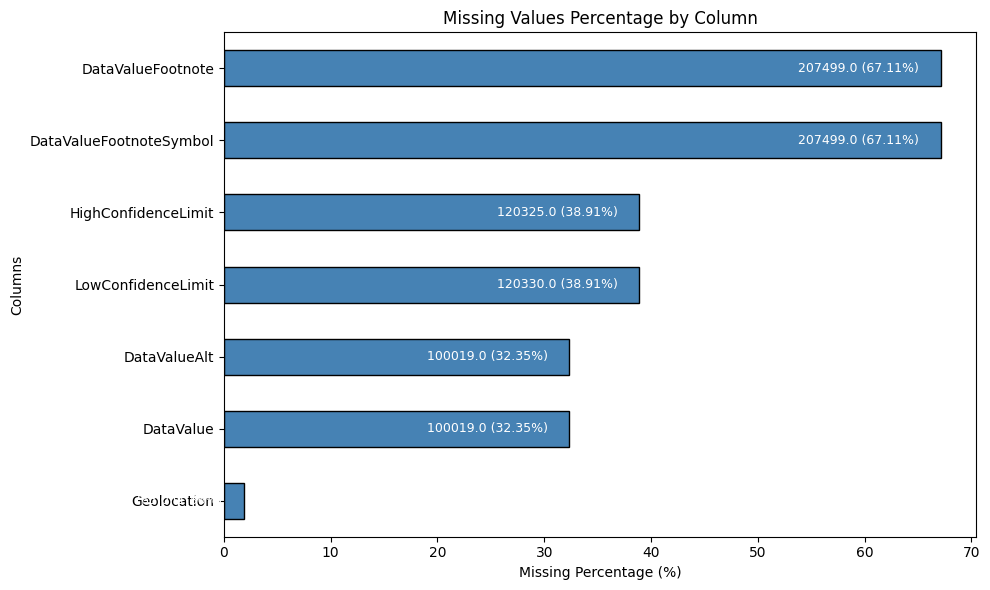

In [29]:
# Horizontal bar plot with values on bars
missing_data = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=True)

ax = missing_data['Missing Percentage'].plot(kind='barh', figsize=(10, 6), color='steelblue', edgecolor='black')
ax.set_title('Missing Values Percentage by Column')
ax.set_xlabel('Missing Percentage (%)')
ax.set_ylabel('Columns')

# Add labels inside bars
for i, (idx, row) in enumerate(missing_data.iterrows()):
    count = row['Missing Count']
    pct = row['Missing Percentage']
    ax.text(pct - 2, i, f'{count} ({pct}%)', va='center', ha='right', fontsize=9, color='white')

plt.tight_layout()
plt.show()

In [30]:
# To look hiden features
pd.set_option('display.max_columns', None)
df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,Number,Age-adjusted Mean,2.9,2.9,NaN,NaN,2.8,2.9,Sex,Female,NaN,59,HEA,HEA04,AGEADJMEAN,SEX,SEXF
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,9537.0,NaN,NaN,NaN,NaN,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,486.0,NaN,NaN,NaN,NaN,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,2880.0,NaN,NaN,NaN,NaN,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,519.0,NaN,NaN,NaN,NaN,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NMBR,RACE,WHT


In [31]:
print(df['DataValueFootnoteSymbol'].value_counts())

DataValueFootnoteSymbol
****    52652
~       28763
*       12833
#        5738
###       937
&         535
##        126
~~~~       84
~~         48
Name: count, dtype: int64


In [32]:
print(df['DataValueFootnote'].value_counts())

DataValueFootnote
Data suppressed; denominator < 50 or relative standard error > 30%                                                      52652
Data suppressed; too few respondents or cases                                                                           28763
No data available                                                                                                       12833
No data available for this indicator because the module was not used by the state or territory                           5738
Interpret with caution: 95% confidence interval width is greater than 20 percentage points or 1.2 times the estimate      937
Interpret with caution; less than 60 respondents                                                                          535
Estimate is 0.0% because no cases were reported with this condition                                                       126
The state registry opted not to present state-specific estimates for this race/ethnicity group      

In [33]:
# Check if NaN values are in the same rows for Footnote couple
both_nan = df['DataValueFootnoteSymbol'].isna() & df['DataValueFootnote'].isna()
only_first_nan = df['DataValueFootnoteSymbol'].isna() & df['DataValueFootnote'].notna()
only_second_nan = df['DataValueFootnoteSymbol'].notna() & df['DataValueFootnote'].isna()

print("DataValueFootnoteSymbol & DataValueFootnote")
print(f"Both are NaN in same row: {both_nan.sum()}")
print(f"Only Symbol is NaN: {only_first_nan.sum()}")
print(f"Only Footnote is NaN: {only_second_nan.sum()}")

if only_first_nan.sum() == 0 and only_second_nan.sum() == 0:
    print("✅ YES: They are NaN in EXACTLY the same rows")
else:
    print("❌ NO: They are NOT the same")

DataValueFootnoteSymbol & DataValueFootnote
Both are NaN in same row: 207499
Only Symbol is NaN: 0
Only Footnote is NaN: 0
✅ YES: They are NaN in EXACTLY the same rows


In [34]:
# Fill NaN in the original dataset
df['DataValueFootnoteSymbol'] = df.groupby('DataValueTypeID')['DataValueFootnoteSymbol'].transform(
    lambda x: x.fillna(method='ffill').fillna(method='bfill')
)

# Check how many NaN remain
remaining_nan = df['DataValueFootnoteSymbol'].isna().sum()
print(f"Remaining NaN in DataValueFootnoteSymbol: {remaining_nan}")

# Show first 20 rows to verify
print("\nFirst 20 rows of original dataset (DataValueTypeID and DataValueFootnoteSymbol):")
print(df[['DataValueTypeID', 'DataValueFootnoteSymbol']].head(20))

Remaining NaN in DataValueFootnoteSymbol: 52

First 20 rows of original dataset (DataValueTypeID and DataValueFootnoteSymbol):
   DataValueTypeID DataValueFootnoteSymbol
0       AGEADJMEAN                    ****
1             NMBR                       ~
2             NMBR                       ~
3             NMBR                       ~
4             NMBR                       ~
5             NMBR                       ~
6             NMBR                       ~
7             NMBR                       ~
8             NMBR                       ~
9             NMBR                       ~
10         CRDRATE                       ~
11         CRDRATE                       ~
12            NMBR                       ~
13         CRDRATE                       ~
14         CRDRATE                       ~
15      AGEADJRATE                       ~
16            NMBR                       ~
17            NMBR                       ~
18            NMBR                       ~
19           

/tmp/ipykernel_2776/4282569626.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_2776/4282569626.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(method='ffill').fillna(method='bfill')


In [35]:
# Fill DataValueFootnote based on same symbol
df['DataValueFootnote'] = df.groupby('DataValueFootnoteSymbol')['DataValueFootnote'].transform(lambda x: x.ffill().bfill())

print(f"Remaining NaN: {df['DataValueFootnote'].isna().sum()}")

Remaining NaN: 52


In [36]:
# Find rows where DataValueFootnote is NaN
nan_rows = df[df['DataValueFootnote'].isna()]

# Show these rows with QuestionID and DataValueFootnote
print(f"Number of NaN rows: {len(nan_rows)}")
print("\nDataValueTypeIDs with their counts:")
print(nan_rows['DataValueTypeID'].value_counts())

# Show first 10 rows
print("\nFirst 10 NaN rows:")
print(nan_rows[['DataValueTypeID', 'DataValueFootnote', 'DataValueFootnoteSymbol']].head(10))

Number of NaN rows: 52

DataValueTypeIDs with their counts:
DataValueTypeID
AGESEXRACEADJRATE    52
Name: count, dtype: int64

First 10 NaN rows:
         DataValueTypeID DataValueFootnote DataValueFootnoteSymbol
17452  AGESEXRACEADJRATE               NaN                     NaN
22142  AGESEXRACEADJRATE               NaN                     NaN
23260  AGESEXRACEADJRATE               NaN                     NaN
27036  AGESEXRACEADJRATE               NaN                     NaN
28523  AGESEXRACEADJRATE               NaN                     NaN
30303  AGESEXRACEADJRATE               NaN                     NaN
31654  AGESEXRACEADJRATE               NaN                     NaN
35292  AGESEXRACEADJRATE               NaN                     NaN
38112  AGESEXRACEADJRATE               NaN                     NaN
38894  AGESEXRACEADJRATE               NaN                     NaN


In [37]:
# Delete rows where DataValueFootnote is NaN
df = df.dropna(subset=['DataValueFootnote'])

print(f"New dataset shape: {df.shape}")

New dataset shape: (309163, 24)


In [38]:
# Define mapping
footnote_mapping = {
    # Keep as is (1 and 2)
    'Data suppressed; denominator < 50 or relative standard error > 30%': 'Data suppressed; denominator < 50 or relative standard error > 30%',
    'Data suppressed; too few respondents or cases': 'Data suppressed; too few respondents or cases',

    # Merge into "Data Suppressed" (3, 4, 9)
    'No data available': 'No Data Available',
    'No data available for this indicator because the module was not used by the state or territory': 'No Data Available',
    'Data cannot be calculated': 'No Data Available',
    'Interpret with caution: 95% confidence interval width is greater than 20 percentage points or 1.2 times the estimate': 'No Data Available',
    'Interpret with caution; less than 60 respondents': 'No Data Available',
}

# Apply mapping
df['DataValueFootnote'] = df['DataValueFootnote'].map(footnote_mapping)

# Delete rows with NaN (7 and 8 that are not mapped)
df = df.dropna(subset=['DataValueFootnote'])

# Check result
print(df['DataValueFootnote'].value_counts())

DataValueFootnote
Data suppressed; denominator < 50 or relative standard error > 30%    153802
Data suppressed; too few respondents or cases                          96163
No Data Available                                                      58454
Name: count, dtype: int64


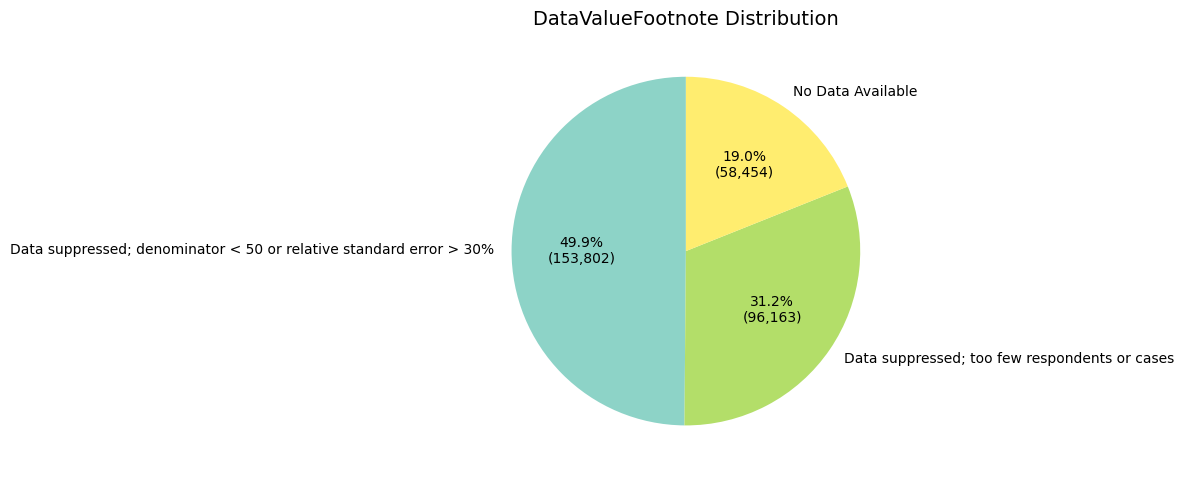

In [39]:
footnote_counts = df['DataValueFootnote'].value_counts()

# Custom autopct to show both percentage and count
def autopct_with_count(pct):
    total = sum(footnote_counts)
    count = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({count:,})'

plt.figure(figsize=(10, 8))
ax = footnote_counts.plot(kind='pie', autopct=autopct_with_count, startangle=90, cmap='Set3')
ax.set_title('DataValueFootnote Distribution', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [40]:
# Rename column
df.rename(columns={'DataValueFootnoteSymbol': 'DataValueFootnoteID'}, inplace=True)

# Define mapping
symbol_to_id = {
    '****': 1,
    '~': 2,
    '*': 3,
    '#': 3,
    '~~': 3,
    '###': 3,
    '&': 3
}

# Apply mapping
df['DataValueFootnoteID'] = df['DataValueFootnoteID'].map(symbol_to_id)

# Delete rows (symbols 7 and 8)
df = df.dropna(subset=['DataValueFootnoteID'])

# Convert to int
df['DataValueFootnoteID'] = df['DataValueFootnoteID'].astype(int)

# Check result
print("DataValueFootnoteID value counts:")
print(df['DataValueFootnoteID'].value_counts().sort_index())

DataValueFootnoteID value counts:
DataValueFootnoteID
1    153802
2     96163
3     58454
Name: count, dtype: int64


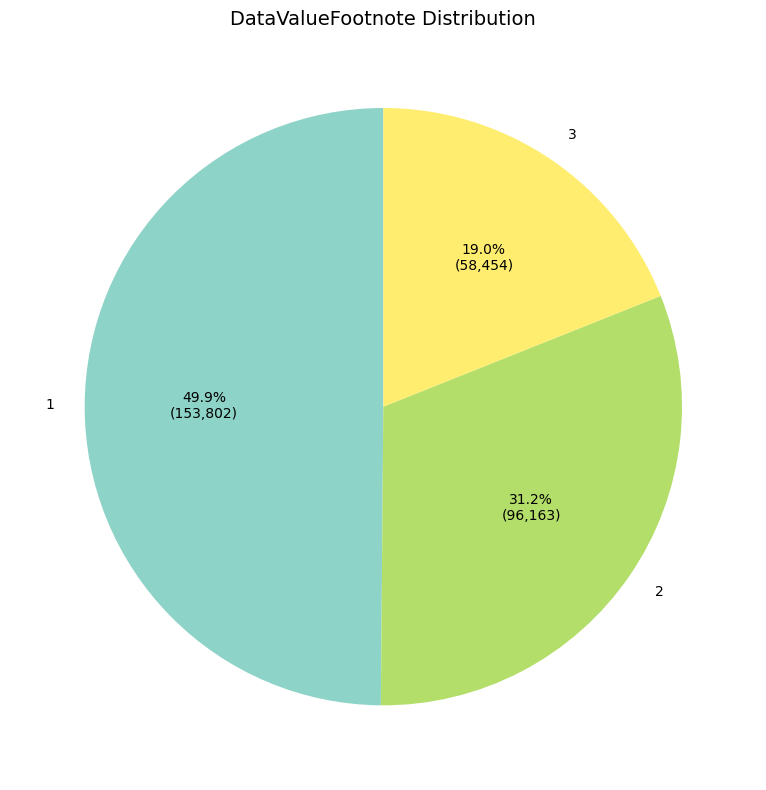

In [41]:
footnote_counts = df['DataValueFootnoteID'].value_counts()

# Custom autopct to show both percentage and count
def autopct_with_count(pct):
    total = sum(footnote_counts)
    count = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({count:,})'

plt.figure(figsize=(10, 8))
ax = footnote_counts.plot(kind='pie', autopct=autopct_with_count, startangle=90, cmap='Set3')
ax.set_title('DataValueFootnote Distribution', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

*I gouped features of DataValueFootnote and DataValueFootnoteSymbol (DataValueFootnoteID) values. It will be usefull in modelling proceses.*

In [42]:
# After filling  and deleting 67% missing values in DataValueFootnoteSymbol and DataValueFootnote features count and percentage
missing = df.isnull().sum()
missing_pct = ((df.isnull().sum() / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print("Missing values:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

Missing values:
                     Missing Count  Missing Percentage
LowConfidenceLimit          119987               38.90
HighConfidenceLimit         119982               38.90
DataValue                    99935               32.40
DataValueAlt                 99935               32.40
Geolocation                   5754                1.87


In [43]:
print(df['LowConfidenceLimit'].value_counts())

LowConfidenceLimit
2.40      838
2.30      757
2.20      746
2.70      744
2.50      738
         ... 
47.31       1
81.22       1
84.75       1
9.45        1
251.80      1
Name: count, Length: 8400, dtype: int64


In [44]:
print(df['HighConfidenceLimit'].value_counts())

HighConfidenceLimit
3.40      562
3.00      555
4.90      522
3.90      520
3.60      519
         ... 
74.53       1
103.96      1
77.99       1
458.80      1
56.09       1
Name: count, Length: 8847, dtype: int64


In [45]:
# Check if NaN values are in the same rows for Confidence couple
both_nan = df['LowConfidenceLimit'].isna() & df['HighConfidenceLimit'].isna()
only_low_nan = df['LowConfidenceLimit'].isna() & df['HighConfidenceLimit'].notna()
only_high_nan = df['LowConfidenceLimit'].notna() & df['HighConfidenceLimit'].isna()

print("\nLowConfidenceLimit & HighConfidenceLimit")
print(f"Both are NaN in same row: {both_nan.sum()}")
print(f"Only Low is NaN: {only_low_nan.sum()}")
print(f"Only High is NaN: {only_high_nan.sum()}")

if only_low_nan.sum() == 0 and only_high_nan.sum() == 0:
    print("✅ YES: They are NaN in EXACTLY the same rows")
else:
    print("❌ NO: They are NOT the same")


LowConfidenceLimit & HighConfidenceLimit
Both are NaN in same row: 119982
Only Low is NaN: 5
Only High is NaN: 0
❌ NO: They are NOT the same


In [46]:
# Delete rows where LowConfidenceLimit is NaN but HighConfidenceLimit is NOT NaN
df = df[~(df['LowConfidenceLimit'].isna() & df['HighConfidenceLimit'].notna())]

print(f"New shape: {df.shape}")
print("5 rows deleted successfully!")

New shape: (308414, 24)
5 rows deleted successfully!


*After checking, I determined that there were 5 mismatched rows in the (LowConfidenceLimit & HighConfidenceLimit) columns. After removing these rows, the NaN values in all feature pairs align row-wise.*

In [47]:
# To fill features of LowConfidenceLimit and HighConfidenceLimit nan values with TopicID.
# (I checked QuestionID and	DataValueTypeID too. But I get the best resuts with TopicID)
df.loc[:, 'LowConfidenceLimit'] = df.groupby('TopicID')['LowConfidenceLimit'].transform(lambda x: x.fillna(x.median()))
df.loc[:, 'HighConfidenceLimit'] = df.groupby('TopicID')['HighConfidenceLimit'].transform(lambda x: x.fillna(x.median()))

In [48]:
# After filling  38% missing values in LowConfidenceLimit and HighConfidenceLimit features count and percentage
missing = df.isnull().sum()
missing_pct = ((df.isnull().sum() / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print("Missing values:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

Missing values:
                     Missing Count  Missing Percentage
DataValue                    99935               32.40
DataValueAlt                 99935               32.40
Geolocation                   5754                1.87
LowConfidenceLimit              52                0.02
HighConfidenceLimit             52                0.02


In [49]:
# Delete rows where LowConfidenceLimit and HighConfidenceLimit are NaN
df = df.dropna(subset=['LowConfidenceLimit', 'HighConfidenceLimit'], how='all')

print(f"New dataset shape: {df.shape}")

New dataset shape: (308362, 24)


In [50]:
print(df['DataValue'].value_counts())

DataValue
3.0         693
2.8         658
4.0         634
3.1         634
2.6         628
           ... 
314982.0      1
5587.0        1
9238.0        1
8102.0        1
2880.0        1
Name: count, Length: 14797, dtype: int64


In [51]:
print(df['DataValueAlt'].value_counts())

DataValueAlt
3.0         693
2.8         658
4.0         634
3.1         634
2.6         628
           ... 
314982.0      1
5587.0        1
9238.0        1
8102.0        1
2880.0        1
Name: count, Length: 14797, dtype: int64


In [52]:
# Check if NaN values are in the same rows for DataValue couple
both_nan = df['DataValue'].isna() & df['DataValueAlt'].isna()
only_value_nan = df['DataValue'].isna() & df['DataValueAlt'].notna()
only_alt_nan = df['DataValue'].notna() & df['DataValueAlt'].isna()

print("\nDataValue & DataValueAlt")
print(f"Both are NaN in same row: {both_nan.sum()}")
print(f"Only DataValue is NaN: {only_value_nan.sum()}")
print(f"Only DataValueAlt is NaN: {only_alt_nan.sum()}")

if only_value_nan.sum() == 0 and only_alt_nan.sum() == 0:
    print("✅ YES: They are NaN in EXACTLY the same rows")
else:
    print("❌ NO: They are NOT the same")


DataValue & DataValueAlt
Both are NaN in same row: 99935
Only DataValue is NaN: 0
Only DataValueAlt is NaN: 0
✅ YES: They are NaN in EXACTLY the same rows


In [53]:
# To fill features of DataValue and DataValueAlt nan values with DataValueTypeID.
df.loc[:, 'DataValue'] = df.groupby('DataValueTypeID')['DataValue'].transform(lambda x: x.fillna(x.median()))
df.loc[:, 'DataValueAlt'] = df.groupby('DataValueTypeID')['DataValueAlt'].transform(lambda x: x.fillna(x.median()))

In [54]:
# After filling  32% missing values in DataValue and DataValueTypeID features count and percentage
missing = df.isnull().sum()
missing_pct = ((df.isnull().sum() / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print("Missing values:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False))

Missing values:
             Missing Count  Missing Percentage
Geolocation           5753                1.87


***Observation:***
 *The feature pairs (DataValueFootnoteSymbol & DataValueFootnote), (LowConfidenceLimit & HighConfidenceLimit), and (DataValue & DataValueAlt) have the same number of NaN values. I suspect that the missing values occur in the same rows.*

In [55]:
df[['LocationID', 'Geolocation']].drop_duplicates()

,LocationID,Geolocation
0,59,NaN
1,5,POINT (-92.27449074299966 34.74865012400045)
2,6,POINT (-120.99999953799971 37.63864012300047)
3,8,POINT (-106.13361092099967 38.843840757000464)
4,13,POINT (-83.62758034599966 32.83968109300048)
5,20,POINT (-98.20078122699965 38.34774030000045)
6,23,POINT (-68.98503133599962 45.254228894000505)
7,34,POINT (-74.27369128799967 40.13057004800049)
8,36,POINT (-75.54397042699964 42.82700103200045)
9,41,POINT (-120.15503132599969 44.56744942400047)


In [56]:
# Feature LocationID 59 in front of Geolocation all line is nan. To look detailed
df[df['LocationID'] == 59]['Geolocation']

,Geolocation
0,NaN
12,NaN
61,NaN
331,NaN
332,NaN
...,...
303225,NaN
303272,NaN
303277,NaN
303282,NaN


In [57]:
# Deleting nan values
df = df[df['Geolocation'].notna()]

In [58]:
df['Geolocation'].isna().sum()

np.int64(0)



***Feature Engineering***

In [59]:
pd.set_option('display.max_columns', None)
df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteID,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,9537.0,2,Data suppressed; too few respondents or cases,40.7,52.4,Sex,Male,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NMBR,SEX,SEXM
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,486.0,2,Data suppressed; too few respondents or cases,40.7,52.4,Overall,Overall,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NMBR,OVERALL,OVR
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,2880.0,2,Data suppressed; too few respondents or cases,40.7,52.4,Race/Ethnicity,Hispanic,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NMBR,RACE,HIS
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,519.0,2,Data suppressed; too few respondents or cases,40.7,52.4,Race/Ethnicity,"White, non-Hispanic",POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NMBR,RACE,WHT
5,2015,2019,KS,Kansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,8102.0,8102.0,2,Data suppressed; too few respondents or cases,40.7,52.4,Sex,Male,POINT (-98.20078122699965 38.34774030000045),20,CAN,CAN07,NMBR,SEX,SEXM


In [60]:
# To dive Latitude and Longitude
df['Latitude'] = df['Geolocation'].str.extract(r'POINT \(([-\d.]+)')
df['Longitude'] = df['Geolocation'].str.extract(r'POINT \([\d.-]+ ([\d.-]+)')

In [61]:
# Insert Year_Span as 3rd column (index 2)
df.insert(2, 'Year_Span', df['YearEnd'] - df['YearStart'])

In [62]:
print(df['DataSource'].value_counts())

DataSource
BRFSS                                          191685
NVSS                                            49237
YRBSS                                           17381
US Cancer DVT                                   16851
CMS Part A Claims Data                          11005
PRAMS                                            7012
NSCH                                             5256
ACS                                              3161
WIC Participant and Program Characteristics       431
NIS                                               212
AEDS                                              162
ANRF                                              162
Current Population Survey - FSS                    54
Name: count, dtype: int64


In [63]:
top5_sources = ['BRFSS', 'NVSS', 'YRBSS', 'US Cancer DVT']

# Group others as 'Other'
df['DataSource'] = df['DataSource'].apply(lambda x: x if x in top5_sources else 'Other')

# Check result
print(df['DataSource'].value_counts())

DataSource
BRFSS            191685
NVSS              49237
Other             27455
YRBSS             17381
US Cancer DVT     16851
Name: count, dtype: int64


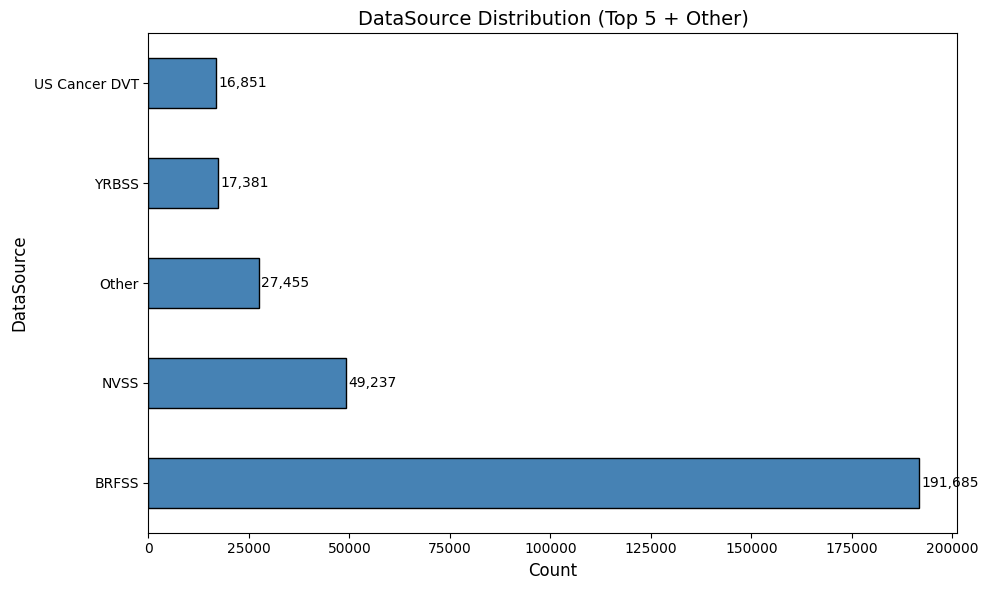

In [64]:
# DataSource Distribution Plot
source_counts = df['DataSource'].value_counts()

ax = source_counts.plot(kind='barh', figsize=(10, 6), color='steelblue', edgecolor='black')
ax.set_title('DataSource Distribution (Top 5 + Other)', fontsize=14)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('DataSource', fontsize=12)

# Add labels
for i, (idx, val) in enumerate(source_counts.items()):
    ax.text(val + 500, i, f"{val:,}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [65]:
print(df['Topic'].value_counts())

Topic
Cardiovascular Disease                             30109
Chronic Obstructive Pulmonary Disease              26377
Nutrition, Physical Activity, and Weight Status    25556
Health Status                                      25049
Alcohol                                            24837
Cancer                                             21595
Immunization                                       18782
Social Determinants of Health                      18648
Arthritis                                          18287
Diabetes                                           16977
Mental Health                                      16575
Tobacco                                            15623
Oral Health                                        12987
Asthma                                             10303
Cognitive Health and Caregiving                     9719
Sleep                                               5216
Disability                                          4967
Maternal Health          

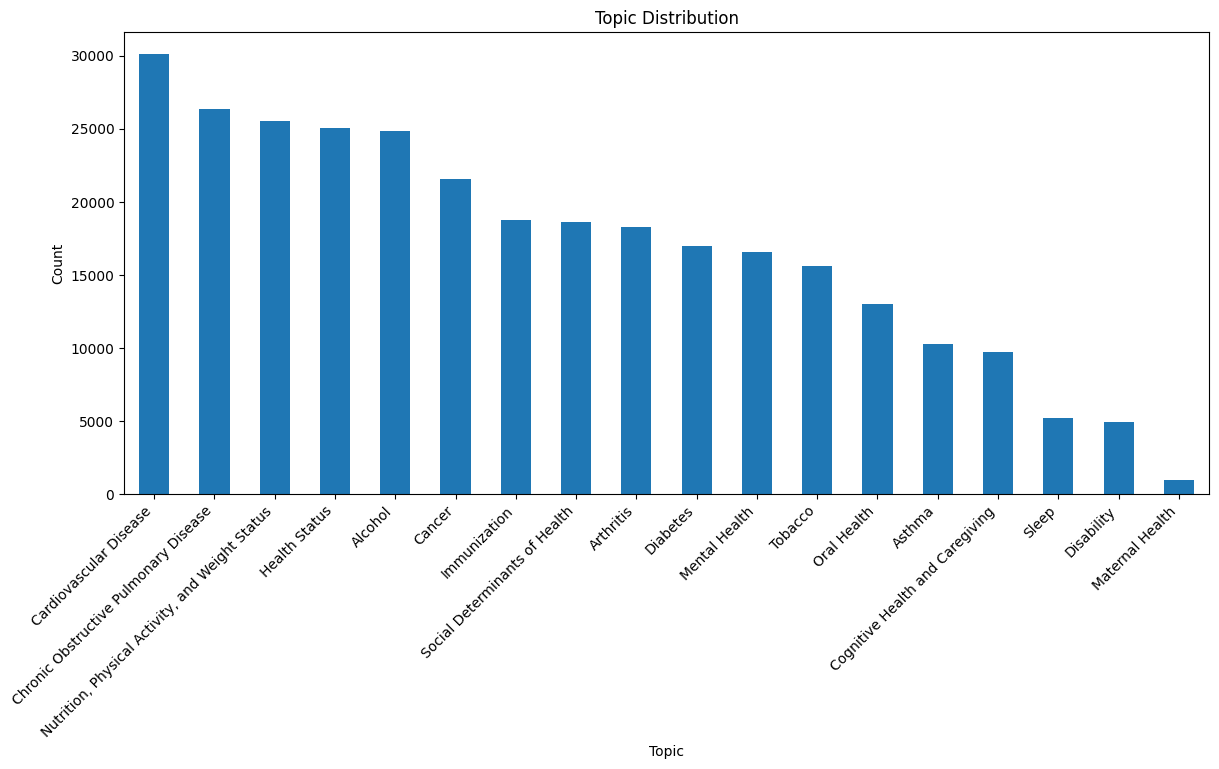

In [66]:
# Topic Distribution direct plot with axis
df['Topic'].value_counts().plot(kind='bar', figsize=(14, 6))
plt.xticks(rotation=45, ha='right')
plt.title('Topic Distribution')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.show()

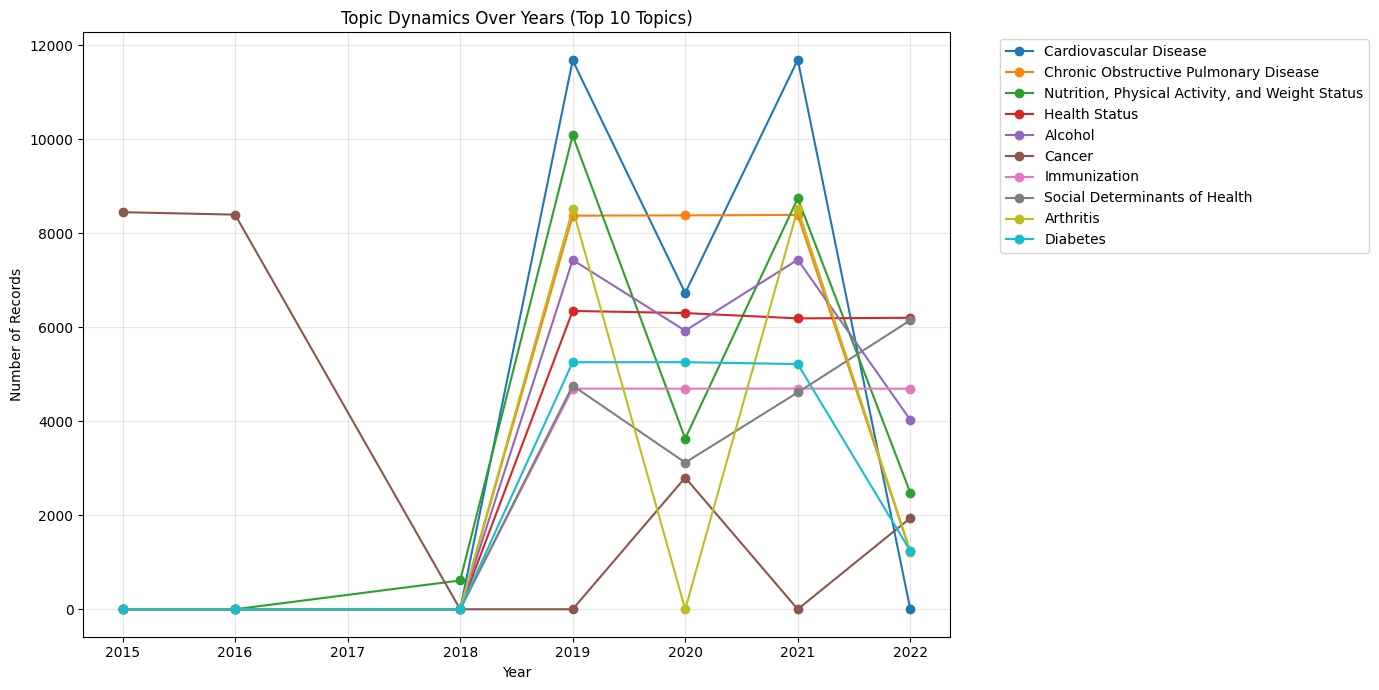

In [67]:
# Group by Year and Topic
topic_yearly = df.groupby(['YearStart', 'Topic']).size().unstack(fill_value=0)

# Get top 10 topics
top_topics = df['Topic'].value_counts().head(10).index

# Plot
ax = topic_yearly[top_topics].plot(figsize=(14, 7), marker='o')
ax.set_title('Topic Dynamics Over Years (Top 10 Topics)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Records')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
# Cancer distribution for Year vs StratificationCategoryID1
cancer_data = df[df['Topic'] == 'Cancer']

# Pivot table: Year vs StratificationCategoryID1
pivot = cancer_data.groupby(['YearStart', 'StratificationCategoryID1']).size().unstack(fill_value=0)

print("Cancer - Year vs StratificationCategoryID1")
print(pivot)

Cancer - Year vs StratificationCategoryID1
StratificationCategoryID1  OVERALL  RACE   SEX
YearStart                                     
2015                          1046  5276  2130
2016                          1051  5238  2110
2020                           323  2264   216
2022                           215  1511   215


In [69]:
# First define years_with_data
cancer_data = df[df['Topic'] == 'Cancer']
years_with_data = cancer_data['YearStart'].value_counts().sort_index()

# Then create summary
summary = pd.DataFrame({
    'Year': sorted(df['YearStart'].unique()),
    'Has_Cancer_Data': [1 if year in years_with_data.index else 0 for year in sorted(df['YearStart'].unique())],
    'Record_Count': [years_with_data.get(year, 0) for year in sorted(df['YearStart'].unique())]
})

print("Cancer Data Collection Summary")
print(summary)

Cancer Data Collection Summary
   Year  Has_Cancer_Data  Record_Count
0  2015                1          8452
1  2016                1          8399
2  2018                0             0
3  2019                0             0
4  2020                1          2803
5  2021                0             0
6  2022                1          1941


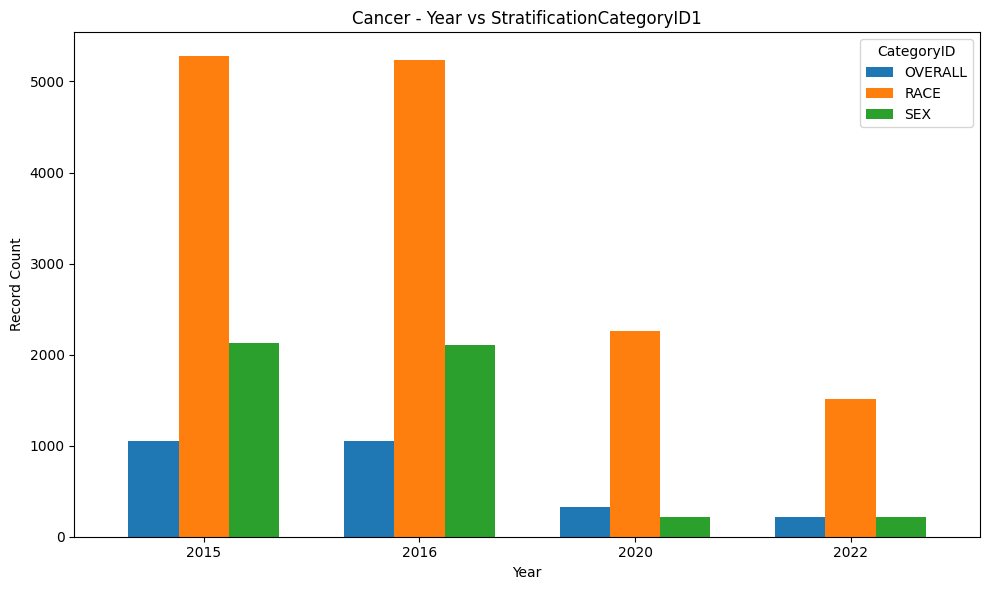

In [70]:
# Cancer distribution for Year vs StratificationCategoryID1 with axis
data = {
    'Year': [2015, 2016, 2020, 2022],
    'OVERALL': [1046, 1051, 323, 215],
    'RACE': [5276, 5238, 2264, 1511],
    'SEX': [2130, 2110, 216, 215]
}

df_viz = pd.DataFrame(data).set_index('Year')

# Plot
ax = df_viz.plot(kind='bar', figsize=(10, 6), width=0.7)
ax.set_title('Cancer - Year vs StratificationCategoryID1')
ax.set_xlabel('Year')
ax.set_ylabel('Record Count')
ax.legend(title='CategoryID')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

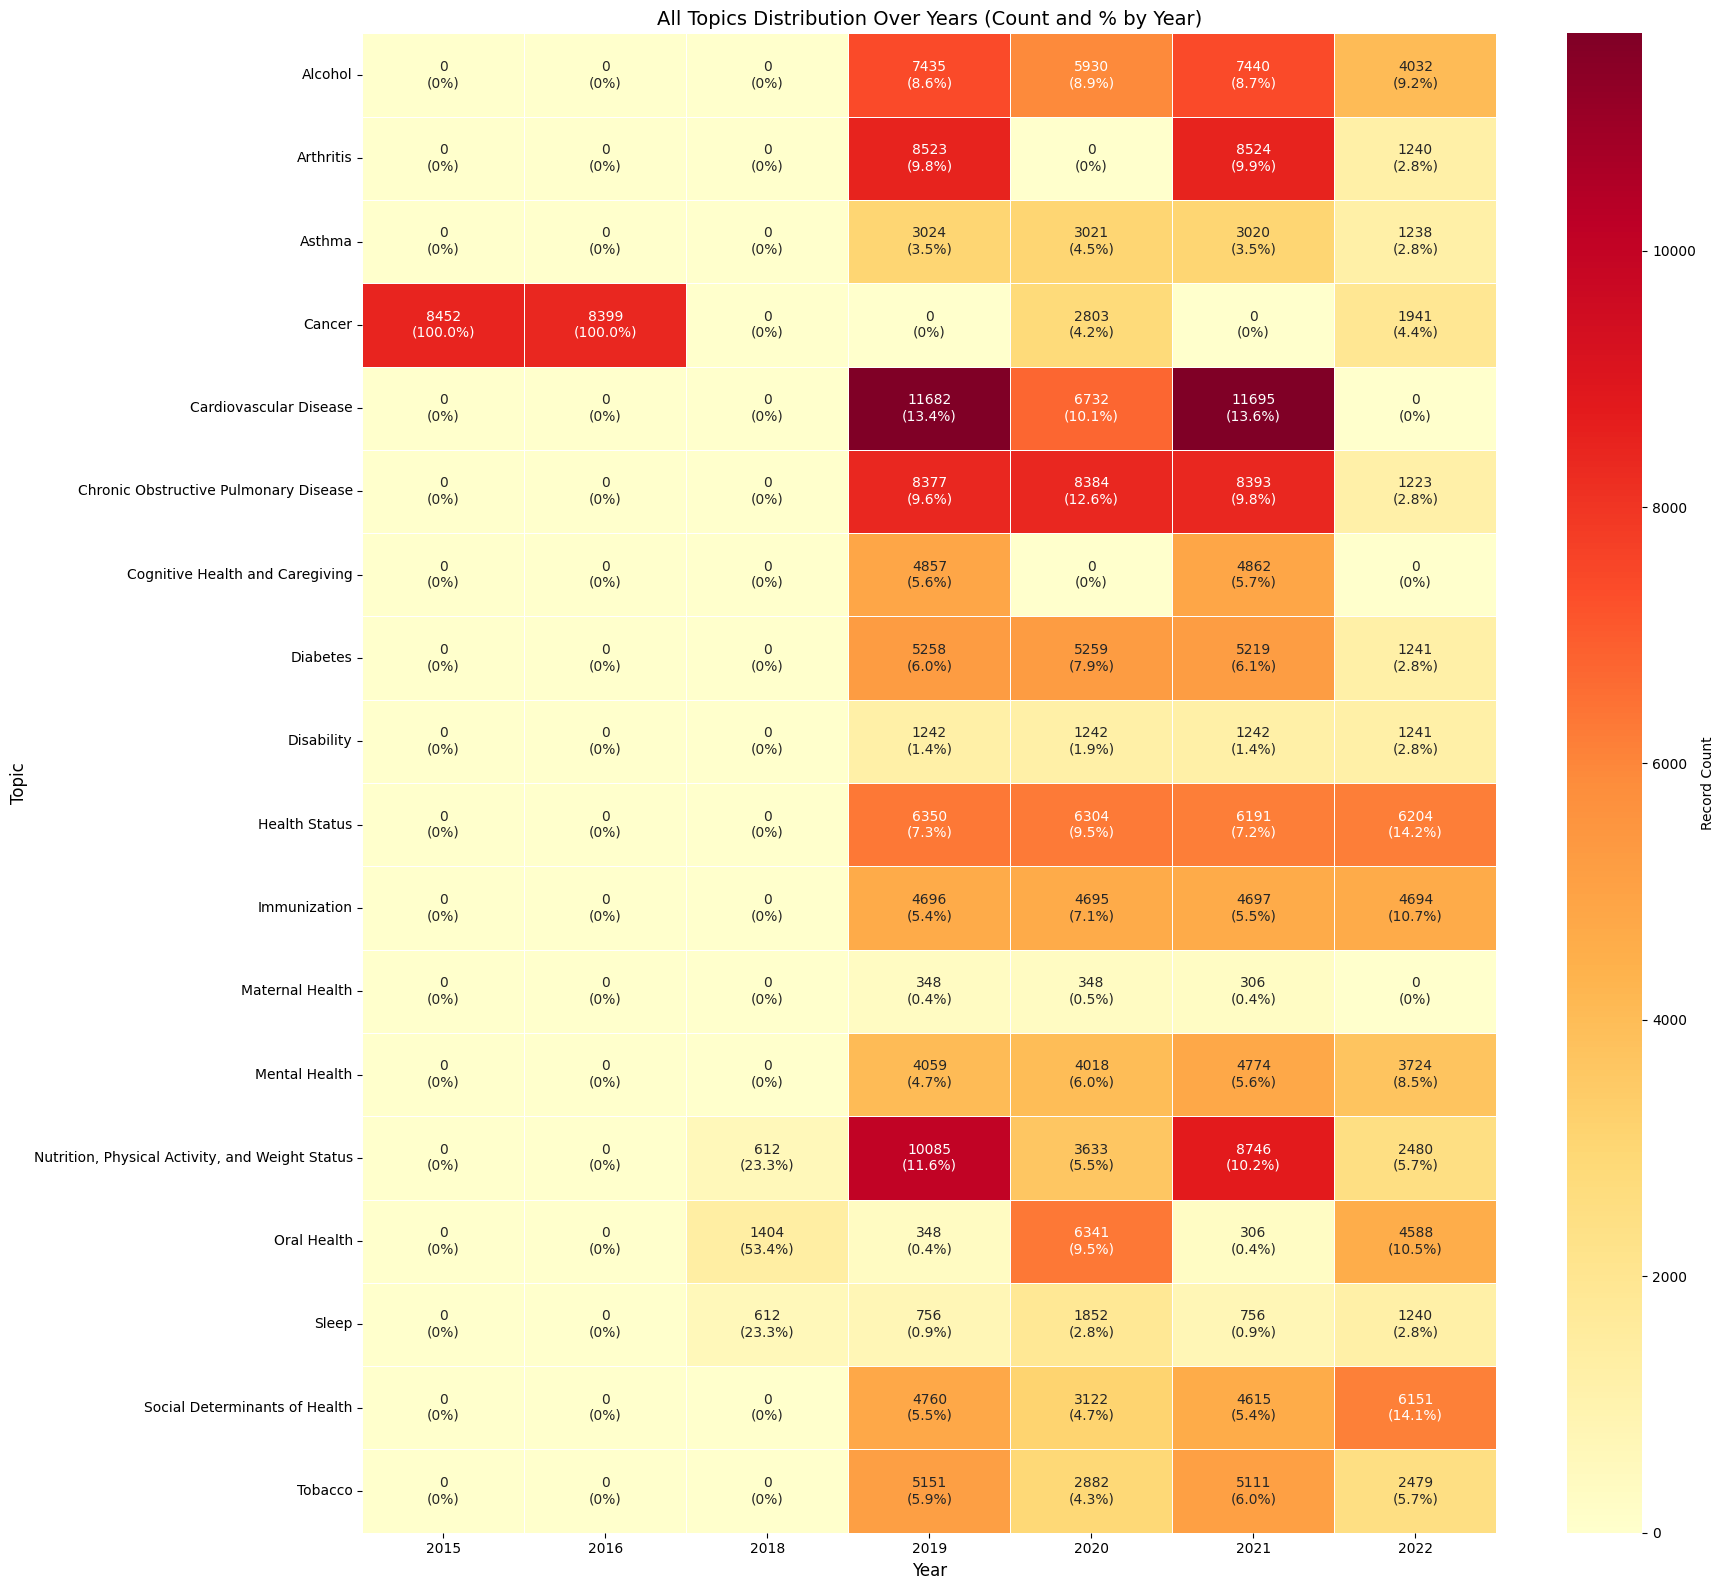

In [71]:
# Create pivot table
all_topics_pivot = df.groupby(['YearStart', 'Topic']).size().unstack(fill_value=0)

# Calculate percentages by row (by year)
pivot_percent = all_topics_pivot.div(all_topics_pivot.sum(axis=1), axis=0) * 100

# Create heatmap with annotations (count and percentage)
plt.figure(figsize=(18, 16))

# Use annot with custom text
annot_text = np.empty(all_topics_pivot.T.shape, dtype=object)
for i in range(all_topics_pivot.T.shape[0]):
    for j in range(all_topics_pivot.T.shape[1]):
        count = all_topics_pivot.T.iloc[i, j]
        pct = pivot_percent.T.iloc[i, j]
        if count > 0:
            annot_text[i, j] = f'{int(count)}\n({pct:.1f}%)'
        else:
            annot_text[i, j] = '0\n(0%)'

ax = sns.heatmap(all_topics_pivot.T, cmap='YlOrRd', annot=annot_text, fmt='',
                 cbar_kws={'label': 'Record Count'}, linewidths=0.5)
ax.set_title('All Topics Distribution Over Years (Count and % by Year)', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
plt.tight_layout()
plt.show()

*When I see Cancer results in heatmap. I think that I lost some information. May be I have done some algoritmic faults.Then I checked some test. Which one I removed after checking. I came result that to collect cancer information has not been every year. We see the same result in 2015 and 2016. They didn't collect information next two years. And statistic numbers are decresed in 2022. They didn't collected 2021 information.*

In [72]:
print(df['DataValueUnit'].value_counts())

DataValueUnit
%                    199419
Number                52821
cases per 100,000     31344
per 100,000           11222
cases per 1,000        7335
Years                   306
gallons                 162
Name: count, dtype: int64


In [73]:
# Delete specified rows
delete_units = ['Years', 'gallons']
df = df[~df['DataValueUnit'].isin(delete_units)]

# Check result
print(df['DataValueUnit'].value_counts())

DataValueUnit
%                    199419
Number                52821
cases per 100,000     31344
per 100,000           11222
cases per 1,000        7335
Name: count, dtype: int64


In [74]:
# Group DataValueUnit
unit_mapping = {
    '%': 'Percent',
    'Number': 'Count',
    'cases per 100,000': 'Rate',
    'per 100,000': 'Rate',
    'cases per 1,000': 'Rate'
}

df['DataValueUnit'] = df['DataValueUnit'].map(unit_mapping)

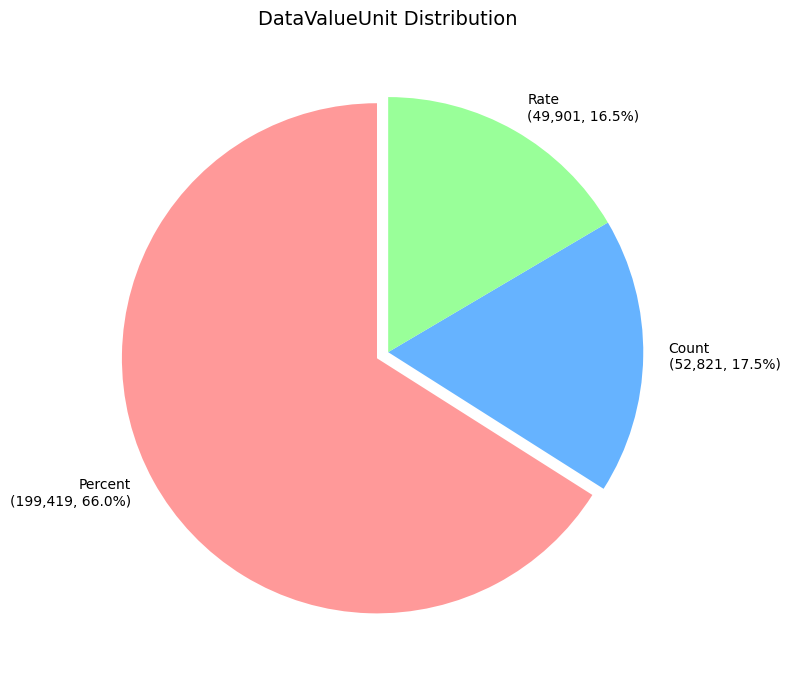

In [75]:
# Pie chart for DataValueUnit with counts and percentages
unit_counts = df['DataValueUnit'].value_counts()

# Create custom labels: Name (Count, Percentage)
labels = [f'{label}\n({count:,}, {count/unit_counts.sum()*100:.1f}%)'
          for label, count in unit_counts.items()]

plt.figure(figsize=(8, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99']
ax = plt.pie(unit_counts, labels=labels, autopct='',
             colors=colors, startangle=90, explode=(0.05, 0, 0))
plt.title('DataValueUnit Distribution', fontsize=14)
plt.tight_layout()
plt.show()

In [76]:
print(df['DataValueTypeID'].value_counts())

DataValueTypeID
CRDPREV       125697
AGEADJPREV     73560
NMBR           26886
CRDRATE        26881
AGEADJRATE     23020
CRDMEAN         8330
AGEADJMEAN      6418
CRDMEDN         5611
CRD75TH         5576
PROP             162
Name: count, dtype: int64


In [77]:
print(df['DataValueType'].value_counts())

DataValueType
Crude Prevalence           125697
Age-adjusted Prevalence     73560
Number                      26886
Crude Rate                  26881
Age-adjusted Rate           23020
Crude Mean                   8330
Age-adjusted Mean            6418
Crude Median                 5611
Crude 75th percentile        5576
Proportion                    162
Name: count, dtype: int64


In [78]:
# Delete both conditions at once
df = df[(df['DataValueTypeID'] != 'PROP') & (df['DataValueType'] != 'Proportion')]

print(f"New dataset shape: {df.shape}")

New dataset shape: (301979, 27)


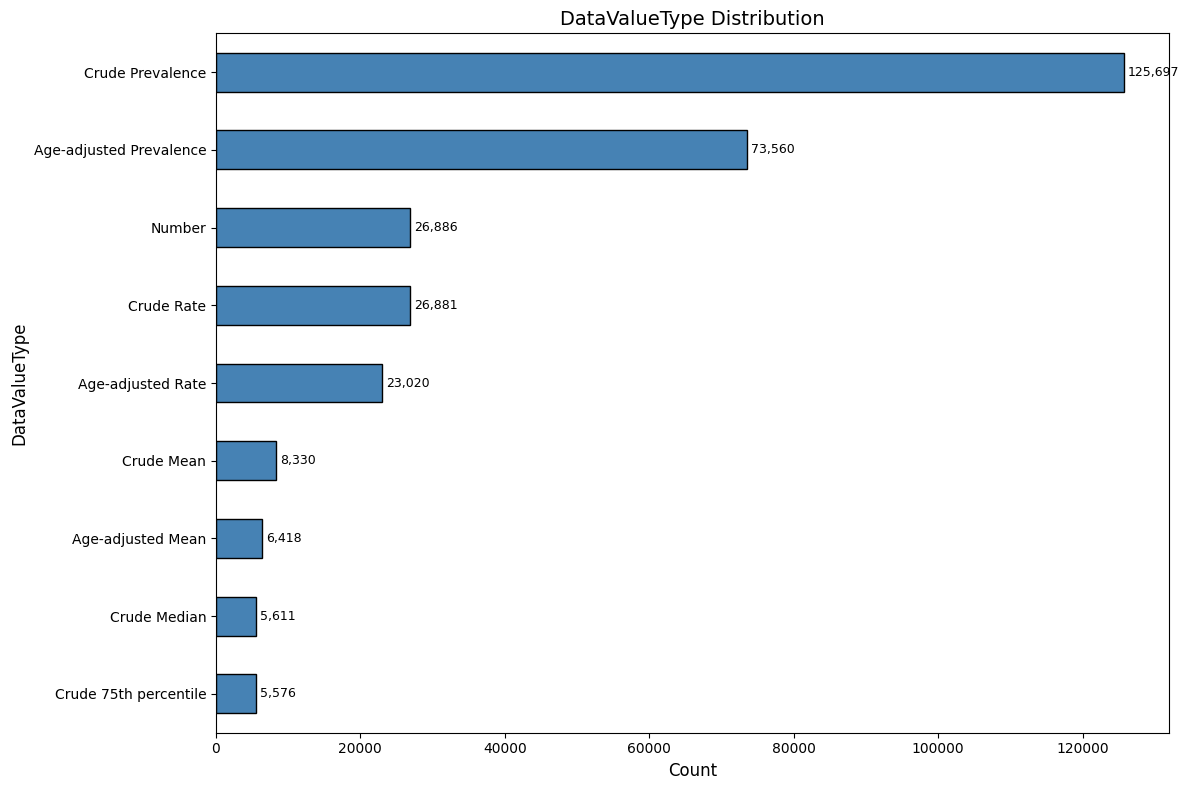

In [79]:
# DataValueType Distribution
datavaluetype_data = {
    'DataValueType': ['Crude Prevalence', 'Age-adjusted Prevalence', 'Number', 'Crude Rate',
                      'Age-adjusted Rate', 'Crude Mean', 'Age-adjusted Mean',
                      'Crude Median', 'Crude 75th percentile'],
    'Count': [125697, 73560, 26886, 26881, 23020, 8330, 6418, 5611, 5576]
}
df_dvt = pd.DataFrame(datavaluetype_data).sort_values('Count', ascending=True)

# Horizontal bar plot
ax = df_dvt.plot(kind='barh', x='DataValueType', y='Count', figsize=(12, 8),
                 color='steelblue', edgecolor='black', legend=False)
ax.set_title('DataValueType Distribution', fontsize=14)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('DataValueType', fontsize=12)

# Add count labels on bars
for i, (idx, row) in enumerate(df_dvt.iterrows()):
    ax.text(row['Count'] + 500, i, f"{row['Count']:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [80]:
print(df['Question'].value_counts())

Question
Binge drinking frequency among adults who binge drink                            5611
Binge drinking intensity among adults who binge drink                            5576
Asthma mortality among all people, underlying cause                              5508
Diabetes mortality among all people, underlying or contributing cause            5507
Cerebrovascular disease (stroke) mortality among all people, underlying cause    5506
                                                                                 ... 
Obesity among WIC children aged 2 to 4 years                                      431
Infants who were exclusively breastfed through 6 months                           106
Infants who were breastfed at 12 months                                           106
No broadband internet subscription among households                               102
Food insecure in the past 12 months among households                               54
Name: count, Length: 105, dtype: int64


In [81]:
print(df['QuestionID'].value_counts())

QuestionID
ALC04    5611
ALC05    5576
AST01    5508
DIA03    5507
CVD07    5506
         ... 
NPW12     431
NPW11     106
NPW10     106
SDH03     102
SDH04      54
Name: count, Length: 105, dtype: int64


In [82]:
print("DataValue & DataValueAlt")
print(f"Rows where DataValue = DataValueAlt: {(df['DataValue'] == df['DataValueAlt']).sum()}")
print(f"Rows where DataValue ≠ DataValueAlt: {(df['DataValue'] != df['DataValueAlt']).sum()}")

# Show examples where they are different
print("\nExamples where they are NOT equal:")
print(df[df['DataValue'] != df['DataValueAlt']][['DataValue', 'DataValueAlt']].head(10))

DataValue & DataValueAlt
Rows where DataValue = DataValueAlt: 301977
Rows where DataValue ≠ DataValueAlt: 2

Examples where they are NOT equal:
       DataValue  DataValueAlt
13106   177511.0     1775112.0
16491   175434.0     1754343.0


##### I will delete DataValueAlt feature next steps, because DataValue and DataValueAlt almost the same.

In [83]:
print(df['StratificationCategory1'].value_counts())

StratificationCategory1
Race/Ethnicity    184655
Sex                52493
Age                31826
Overall            28041
Grade               4964
Name: count, dtype: int64


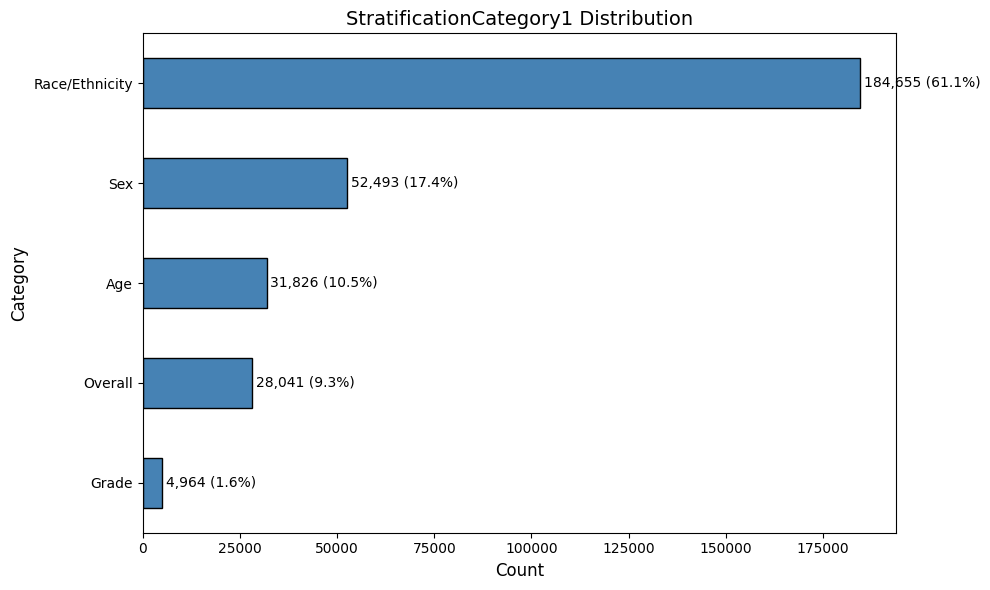

In [84]:
# StratificationCategory1 Distribution
strat_cat_data = {
    'Category': ['Race/Ethnicity', 'Sex', 'Age', 'Overall', 'Grade'],
    'Count': [184655, 52493, 31826, 28041, 4964]
}
df_strat = pd.DataFrame(strat_cat_data).sort_values('Count', ascending=True)

# Calculate percentage
total = df_strat['Count'].sum()
df_strat['Percentage'] = (df_strat['Count'] / total * 100).round(1)

# Horizontal bar plot
ax = df_strat.plot(kind='barh', x='Category', y='Count', figsize=(10, 6),
                   color='steelblue', edgecolor='black', legend=False)
ax.set_title('StratificationCategory1 Distribution', fontsize=14)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

# Add count and percentage labels on bars
for i, (idx, row) in enumerate(df_strat.iterrows()):
    ax.text(row['Count'] + 1000, i, f"{row['Count']:,} ({row['Percentage']}%)",
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [85]:
print(df['StratificationCategoryID1'].value_counts())

StratificationCategoryID1
RACE       184655
SEX         52493
AGE         31826
OVERALL     28041
GRADE        4964
Name: count, dtype: int64


In [86]:
print(df['Stratification1'].value_counts())

Stratification1
Overall                                           28041
Hispanic                                          27400
White, non-Hispanic                               27396
Black, non-Hispanic                               27393
American Indian or Alaska Native, non-Hispanic    27376
Male                                              26247
Female                                            26246
Hawaiian or Pacific Islander, non-Hispanic        23893
Multiracial, non-Hispanic                         23847
Asian, non-Hispanic                               23815
Age 45-64                                         10943
Age >=65                                           9707
Age 18-44                                          7980
Asian or Pacific Islander, non-Hispanic            3535
Age 0-44                                           2140
Grade 10                                           1242
Grade 11                                           1242
Grade 12                        

In [87]:
# Define mapping for Stratification1
strat_mapping = {
    # Grade groups
    'Grade 9': 'Grade_teen',
    'Grade 10': 'Grade_teen',
    'Grade 11': 'Grade_teen',
    'Grade 12': 'Grade_teen',

    # Age groups (except Age 0-44)
    'Age 1-5': 'Child',
    'Age 4 m - 5 y': 'Child',
    'Age 6-9': 'Child',
    'Age 6-11': 'Child',
    'Age 6-14': 'Child',
    'Age 10-13': 'Child',
    'Age 12-17': 'Grade_teen',
    'Age 18-44': 'Adult',
    'Age 45-64': 'Old',
    'Age >=65': 'Old'
}

# Copy original column
df['Stratification1_Grouped'] = df['Stratification1'].copy()

# Apply grade mapping
grade_values = ['Grade 9', 'Grade 10', 'Grade 11', 'Grade 12']
df.loc[df['Stratification1'].isin(grade_values), 'Stratification1_Grouped'] = 'Grade_teen'

# Apply age mappings (except Age 0-44)
age_child = ['Age 1-5', 'Age 4 m - 5 y', 'Age 6-9', 'Age 6-11', 'Age 6-14', 'Age 10-13']
age_teen = ['Age 12-17']
age_adult = ['Age 18-44']
age_old = ['Age 45-64', 'Age >=65']

df.loc[df['Stratification1'].isin(age_child), 'Stratification1_Grouped'] = 'Child'
df.loc[df['Stratification1'].isin(age_teen), 'Stratification1_Grouped'] = 'Grade_teen'
df.loc[df['Stratification1'].isin(age_adult), 'Stratification1_Grouped'] = 'Adult'
df.loc[df['Stratification1'].isin(age_old), 'Stratification1_Grouped'] = 'Old'

# Handle Age 0-44 - split into 3 equal parts
import numpy as np

np.random.seed(42)
age_0_44_indices = df[df['Stratification1'] == 'Age 0-44'].index
split_random = np.random.choice(['Child', 'Grade_teen', 'Adult'], size=len(age_0_44_indices), p=[1/3, 1/3, 1/3])
df.loc[age_0_44_indices, 'Stratification1_Grouped'] = split_random

# Check result
print("Distribution after grouping:")
print(df['Stratification1_Grouped'].value_counts())

Distribution after grouping:
Stratification1_Grouped
Overall                                           28041
Hispanic                                          27400
White, non-Hispanic                               27396
Black, non-Hispanic                               27393
American Indian or Alaska Native, non-Hispanic    27376
Male                                              26247
Female                                            26246
Hawaiian or Pacific Islander, non-Hispanic        23893
Multiracial, non-Hispanic                         23847
Asian, non-Hispanic                               23815
Old                                               20650
Adult                                              8691
Grade_teen                                         5892
Asian or Pacific Islander, non-Hispanic            3535
Child                                              1557
Name: count, dtype: int64


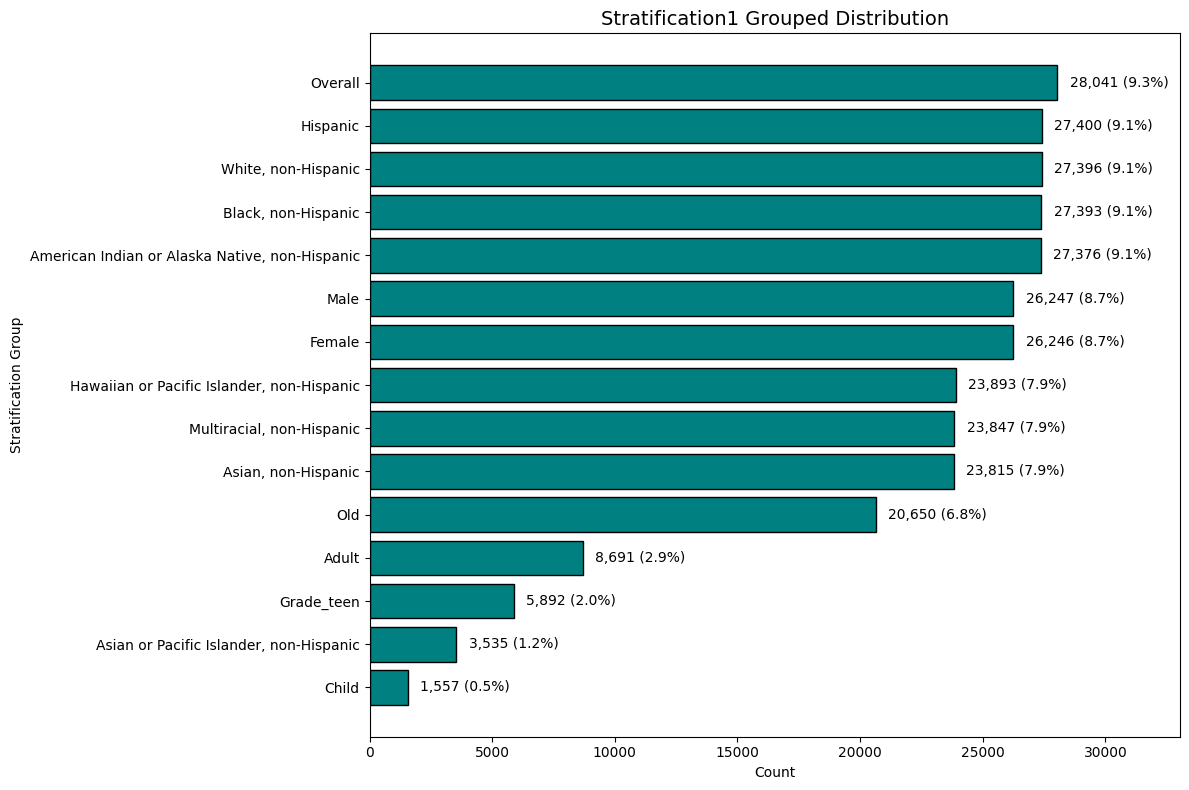

In [88]:
# Stratification1 Grouped Distribution
strat_grouped_counts = df['Stratification1_Grouped'].value_counts()
fig, ax = plt.subplots(figsize=(12, 8))

# Sort values
strat_grouped_counts.sort_values(inplace=True)
total = sum(strat_grouped_counts)

# Create bar chart
bars = ax.barh(strat_grouped_counts.index, strat_grouped_counts.values, color='teal', edgecolor='black')

# Add labels (count + percentage)
for bar, count in zip(bars, strat_grouped_counts.values):
    pct = (count / total) * 100
    ax.text(count + 500, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=10)

ax.set_title('Stratification1 Grouped Distribution', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Stratification Group')
ax.set_xlim(0, strat_grouped_counts.max() + 5000)

plt.tight_layout()
plt.show()

In [89]:
print(df['StratificationID1'].value_counts())

StratificationID1
OVR        28041
HIS        27400
WHT        27396
BLK        27393
AIAN       27376
SEXM       26247
SEXF       26246
HAPI       23893
MRC        23847
ASN        23815
AGE4564    10943
AGE65P      9707
AGE1844     7980
API         3535
AGE0_44     2140
GRD10       1242
GRD11       1242
GRD12       1240
GRD9        1240
AGE1217      216
AGE6_11      216
AGE1_5       216
AGE6_14      102
AGE4M5Y      102
AGE6_9       102
AGE1013      102
Name: count, dtype: int64


In [90]:
# Create new column for grouped ID
df['StratificationGroupID'] = df['StratificationID1'].copy()

# Grade groups
grade_ids = ['GRD9', 'GRD10', 'GRD11', 'GRD12']
df.loc[df['StratificationID1'].isin(grade_ids), 'StratificationGroupID'] = 'GRDTEN'

# Age groups (except AGE0_44)
child_ids = ['AGE1_5', 'AGE4M5Y', 'AGE6_9', 'AGE6_11', 'AGE6_14', 'AGE1013']
teen_ids = ['AGE1217']
adult_ids = ['AGE1844']
old_ids = ['AGE4564', 'AGE65P']

df.loc[df['StratificationID1'].isin(child_ids), 'StratificationGroupID'] = 'CHD'
df.loc[df['StratificationID1'].isin(teen_ids), 'StratificationGroupID'] = 'GRDTEN'
df.loc[df['StratificationID1'].isin(adult_ids), 'StratificationGroupID'] = 'ADT'
df.loc[df['StratificationID1'].isin(old_ids), 'StratificationGroupID'] = 'OLD'

# Handle AGE0_44 - split into 3 equal parts
import numpy as np

np.random.seed(42)
age0_44_indices = df[df['StratificationID1'] == 'AGE0_44'].index
split_age0 = np.random.choice(['CHD', 'GRDTEN', 'ADT'], size=len(age0_44_indices), p=[1/3, 1/3, 1/3])
df.loc[age0_44_indices, 'StratificationGroupID'] = split_age0

# Check result
print("StratificationGroupID distribution:")
print(df['StratificationGroupID'].value_counts())

StratificationGroupID distribution:
StratificationGroupID
OVR       28041
HIS       27400
WHT       27396
BLK       27393
AIAN      27376
SEXM      26247
SEXF      26246
HAPI      23893
MRC       23847
ASN       23815
OLD       20650
ADT        8691
GRDTEN     5892
API        3535
CHD        1557
Name: count, dtype: int64


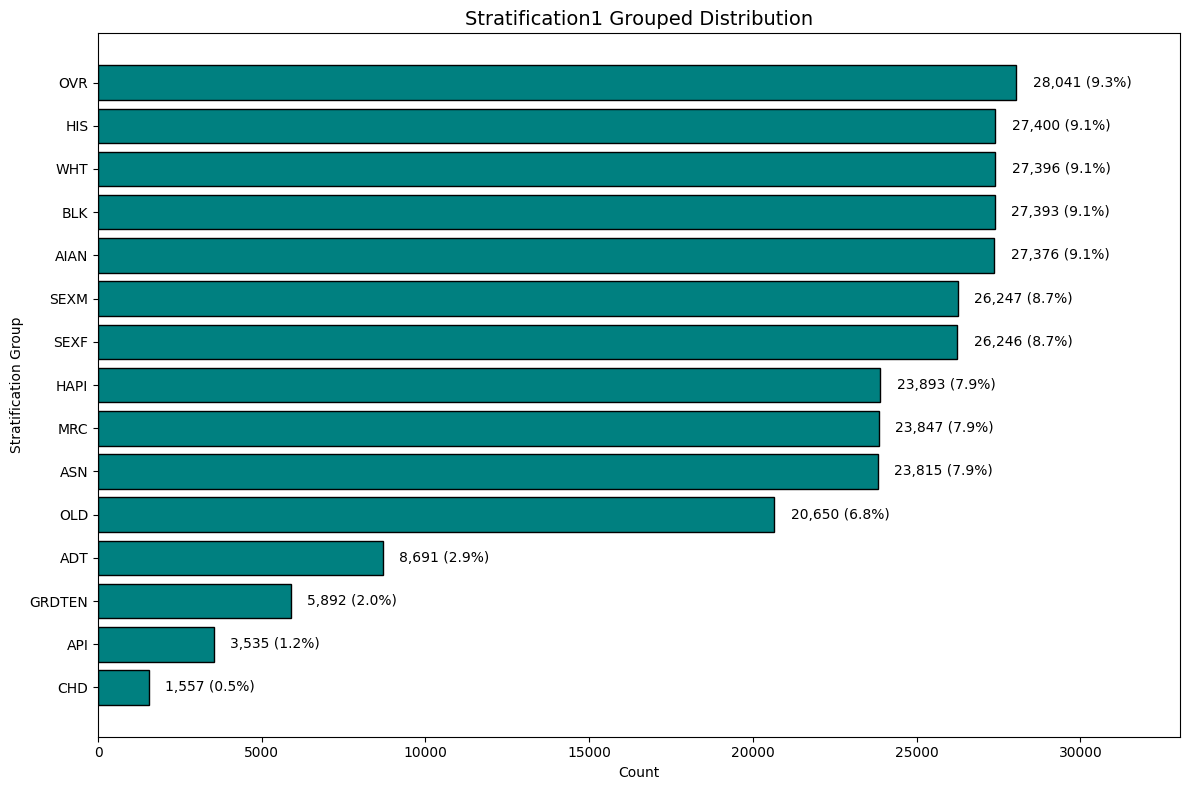

In [91]:
# Stratification1 Grouped Distribution

strat_grouped_counts = df['StratificationGroupID'].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))

# Sort values
strat_grouped_counts.sort_values(inplace=True)
total = sum(strat_grouped_counts)

# Create bar chart
bars = ax.barh(strat_grouped_counts.index, strat_grouped_counts.values, color='teal', edgecolor='black')

# Add labels (count + percentage)
for bar, count in zip(bars, strat_grouped_counts.values):
    pct = (count / total) * 100
    ax.text(count + 500, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=10)

ax.set_title('Stratification1 Grouped Distribution', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Stratification Group')
ax.set_xlim(0, strat_grouped_counts.max() + 5000)

plt.tight_layout()
plt.show()

In [92]:
df.describe()                      # for numeric columns
df.describe(include='object')      # for categorical columns

,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValueFootnote,StratificationCategory1,Stratification1,Geolocation,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1,Latitude,Longitude,Stratification1_Grouped,StratificationGroupID
count,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979,301979
unique,54,54,5,18,105,3,9,3,5,26,54,18,105,9,5,26,54,54,15,15
top,GA,Georgia,BRFSS,Cardiovascular Disease,Binge drinking frequency among adults who bing...,Percent,Crude Prevalence,Data suppressed; denominator < 50 or relative ...,Race/Ethnicity,Overall,POINT (-83.62758034599966 32.83968109300048),CVD,ALC04,CRDPREV,RACE,OVR,-83.62758034599966,32.83968109300048,Overall,OVR
freq,5730,5730,191685,30109,5611,199257,125697,151603,184655,28041,5730,30109,5611,125697,184655,28041,5730,5730,28041,28041


In [93]:
df1 = df.drop(columns=['LocationDesc', 'Topic', 'Question', 'DataValueType', 'DataValueFootnote', 'StratificationCategory1', 'Stratification1',  'Geolocation',  'DataValueAlt', 'StratificationID1', 'Stratification1_Grouped', 'YearStart', 'YearEnd', 'LowConfidenceLimit', 'HighConfidenceLimit', 'QuestionID', 'Latitude', 'Longitude'])

*COLUMN REMOVAL EXPLANATION*

The following columns were removed from the dataset for specific reasons:

1. DUPLICATE / REDUNDANT COLUMNS (To prevent Data Leakage):
   - LocationDesc (duplicate of LocationAbbr)
   - Topic (duplicate of TopicID)
   - Question (duplicate of QuestionID)
   - DataValueType (duplicate of DataValueTypeID)
   - StratificationCategory1 (duplicate of StratificationCategoryID1)
   - Stratification1 (duplicate of StratificationID1)
   - Stratification1_Grouped (duplicate of StratificationGroupID)
   - Geolocation (split into Latitude & Longitude)
   - DataValueAlt (duplicate of DataValue)

   REASON: These columns contain the same information as their ID/abbreviated
   versions. Keeping both would cause data leakage and multicollinearity.

2. HIGH CARDINALITY COLUMNS (To maintain model performance):
   - QuestionID (105 unique values)
   - YearStart, YearEnd (already used to create Year_Span)
   - LowConfidenceLimit, HighConfidenceLimit (already used to create Confidence_Width)

   REASON: High cardinality features can slow down training and cause overfitting.
   We extracted relevant information (Year_Span, Confidence_Width) and dropped the originals.

3. NOT SUITABLE AS TARGET (Based on project objectives):
   - All removed columns were not aligned with our 3 prediction targets:
     * DataValue (disease rate - main target)
     * DataValueUnit (unit type - classification target)
     * DataValueTypeID (value type - classification target)

  

In [94]:
pd.set_option('display.max_columns', None)
df1.head()

,Year_Span,LocationAbbr,DataSource,DataValueUnit,DataValue,DataValueFootnoteID,LocationID,TopicID,DataValueTypeID,StratificationCategoryID1,StratificationGroupID
1,4,AR,US Cancer DVT,Count,9537.0,2,5,CAN,NMBR,SEX,SEXM
2,4,CA,US Cancer DVT,Count,486.0,2,6,CAN,NMBR,OVERALL,OVR
3,4,CO,US Cancer DVT,Count,2880.0,2,8,CAN,NMBR,RACE,HIS
4,4,GA,US Cancer DVT,Count,519.0,2,13,CAN,NMBR,RACE,WHT
5,4,KS,US Cancer DVT,Count,8102.0,2,20,CAN,NMBR,SEX,SEXM


In [95]:
df1.describe()                      # for numeric columns
df1.describe(include='object')      # for categorical columns

,LocationAbbr,DataSource,DataValueUnit,TopicID,DataValueTypeID,StratificationCategoryID1,StratificationGroupID
count,301979,301979,301979,301979,301979,301979,301979
unique,54,5,3,18,9,5,15
top,GA,BRFSS,Percent,CVD,CRDPREV,RACE,OVR
freq,5730,191685,199257,30109,125697,184655,28041


# ***Modelling***

**I will choose 3 Target features and I will work one by one them.**
**Target features are DataValue, DataValueUnit and DataValueTypeID**

**To make models for DataValue**

In [96]:
df_value = df1.copy()

In [97]:
X_value = df_value.drop(columns=['DataValue'])
y_value = df_value['DataValue']

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X_value,
    y_value,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (241583, 10)
Test size: (60396, 10)


In [99]:
# To change categoric features to numeric in train test
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [100]:
# One-Hot Encoding for specified columns
onehot_cols = ['DataSource', 'DataValueUnit', 'DataValueTypeID', 'StratificationCategoryID1']
df_value = pd.get_dummies(
    df_value,
    columns=onehot_cols,
    drop_first=True,
    dtype=int
)

# Label Encoding for specified columns
label_cols = ['LocationAbbr', 'TopicID', 'StratificationGroupID']
for col in label_cols:
    le = LabelEncoder()
    df_value[col] = le.fit_transform(df_value[col])

# Check result
print(f"df_value shape after encoding: {df_value.shape}")
print(f"Columns: {df_value.columns.tolist()}")

df_value shape after encoding: (301979, 25)
Columns: ['Year_Span', 'LocationAbbr', 'DataValue', 'DataValueFootnoteID', 'LocationID', 'TopicID', 'StratificationGroupID', 'DataSource_NVSS', 'DataSource_Other', 'DataSource_US Cancer DVT', 'DataSource_YRBSS', 'DataValueUnit_Percent', 'DataValueUnit_Rate', 'DataValueTypeID_AGEADJPREV', 'DataValueTypeID_AGEADJRATE', 'DataValueTypeID_CRD75TH', 'DataValueTypeID_CRDMEAN', 'DataValueTypeID_CRDMEDN', 'DataValueTypeID_CRDPREV', 'DataValueTypeID_CRDRATE', 'DataValueTypeID_NMBR', 'StratificationCategoryID1_GRADE', 'StratificationCategoryID1_OVERALL', 'StratificationCategoryID1_RACE', 'StratificationCategoryID1_SEX']


In [101]:
df_value.head()

,Year_Span,LocationAbbr,DataValue,DataValueFootnoteID,LocationID,TopicID,StratificationGroupID,DataSource_NVSS,DataSource_Other,DataSource_US Cancer DVT,DataSource_YRBSS,DataValueUnit_Percent,DataValueUnit_Rate,DataValueTypeID_AGEADJPREV,DataValueTypeID_AGEADJRATE,DataValueTypeID_CRD75TH,DataValueTypeID_CRDMEAN,DataValueTypeID_CRDMEDN,DataValueTypeID_CRDPREV,DataValueTypeID_CRDRATE,DataValueTypeID_NMBR,StratificationCategoryID1_GRADE,StratificationCategoryID1_OVERALL,StratificationCategoryID1_RACE,StratificationCategoryID1_SEX
1,4,2,9537.0,2,5,3,13,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,4,4,486.0,2,6,3,11,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0
3,4,5,2880.0,2,8,3,8,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
4,4,10,519.0,2,13,3,14,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
5,4,17,8102.0,2,20,3,13,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1


In [104]:
# Creation of models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    print(f"\n{name}")
    print(f"R²: {r2:.3f}")
    print(f"RMSE: {rmse:.2f}")


Linear Regression
R²: 0.031
RMSE: 5618.56

Decision Tree
R²: 0.851
RMSE: 2200.45

Random Forest
R²: 0.746
RMSE: 2877.01

XGBoost
R²: 0.862
RMSE: 2123.41


*Hyperparametr turning for DataValue*

In [105]:
# Hyperparameter tuning is applied because XGBRegressor is the best model.

In [106]:
# Parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBRegressor(random_state=42, verbosity=0)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting Randomized Search...")
random_search.fit(X_train, y_train)

print("\nBest parameters:", random_search.best_params_)
print("Best R2 score (CV):", round(random_search.best_score_, 3))

# Evaluate best model
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"\nTest set performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

Starting Randomized Search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best R2 score (CV): 0.501

Test set performance:
RMSE: 2619.52
R2: 0.789


/tmp/ipykernel_2776/1642379261.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


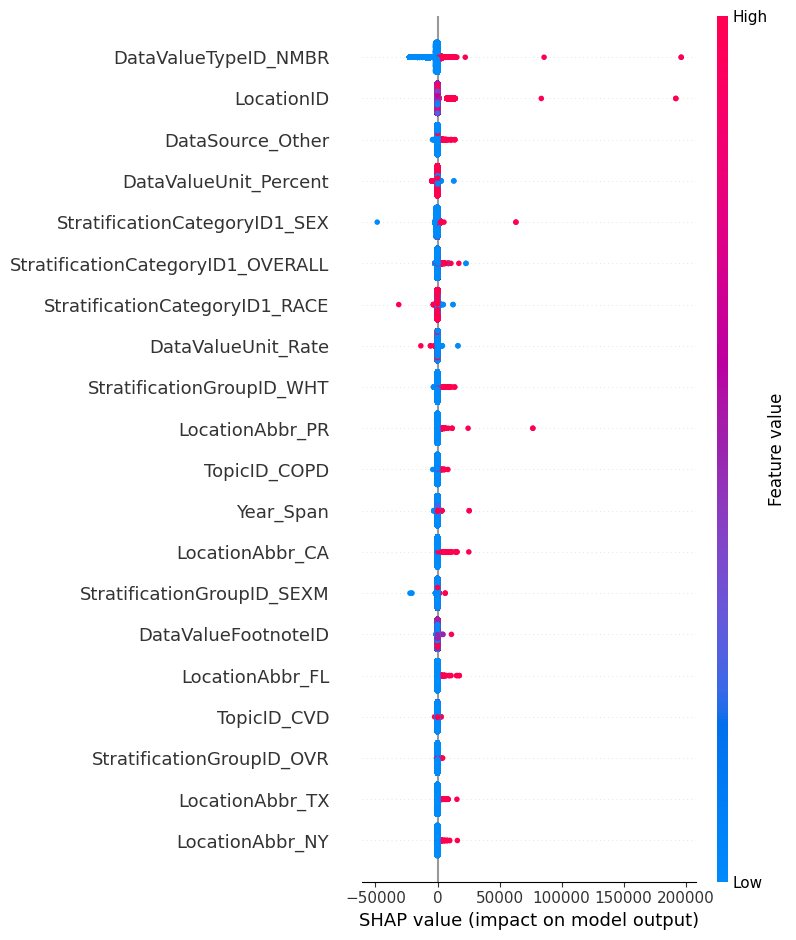

In [107]:
# To create SHAP Explainer
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [108]:
# Feature importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

                               Feature  Importance
42                     LocationAbbr_PR    0.222878
2                           LocationID    0.192565
103         StratificationGroupID_SEXM    0.064145
90       StratificationCategoryID1_SEX    0.057696
86                DataValueTypeID_NMBR    0.044834
11                     LocationAbbr_FL    0.034770
101          StratificationGroupID_OVR    0.026403
88   StratificationCategoryID1_OVERALL    0.025937
61                  DataValueUnit_Rate    0.025555
6                      LocationAbbr_CA    0.024578
37                     LocationAbbr_NY    0.017796
57                    DataSource_Other    0.017582
25                     LocationAbbr_MI    0.017503
1                  DataValueFootnoteID    0.017458
38                     LocationAbbr_OH    0.017375
89      StratificationCategoryID1_RACE    0.017178
41                     LocationAbbr_PA    0.013940
17                     LocationAbbr_IL    0.013023
85             DataValueTypeID_

**To make model for DataValueUnit**

In [110]:
# Create df_unit for DataValueUnit target
df_unit = df1.copy()

In [111]:
# DataValueTypeID feature making data leakage. Accuracy and F1-score result were 1.0 before drop DataValueTypeID
df_unit = df_unit.drop(columns=['DataValueTypeID'])

In [112]:
# Lable encoding DataValueUnit (target) feature
le_target = LabelEncoder()
y = le_target.fit_transform(df_unit['DataValueUnit'])

In [113]:
X = df_unit.drop(columns=['DataValueUnit'])

In [114]:
onehot_cols = [
    'DataSource',
    'StratificationCategoryID1'
]

X = pd.get_dummies(
    X,
    columns=onehot_cols,
    drop_first=True,
    dtype=int
)

In [115]:
label_cols = [
    'LocationAbbr',
    'TopicID',
    'StratificationGroupID'
]

for col in label_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [117]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [118]:
# Creation Models
models = {
    'Logistic Regression': LogisticRegression(solver='saga', C=0.1,max_iter=10000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
}

In [119]:
results = {}

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'Accuracy': acc,
        'F1-score': f1
    }

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")


Logistic Regression
Accuracy: 0.7136
F1-score: 0.6317

Decision Tree
Accuracy: 0.9791
F1-score: 0.9791

Random Forest
Accuracy: 0.9824
F1-score: 0.9824

XGBoost
Accuracy: 0.9781
F1-score: 0.9781


Hyperparametr for DatValueUnit

In [120]:
# Hyperparametr tuning for LogisticRegression with RandomizedSearchCV

param_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

lr = LogisticRegression(max_iter=2000)

grid_lr = RandomizedSearchCV(
    lr,
    param_lr,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_lr.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=LogisticRegression(max_iter=2000), n_iter=5,
                   n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'solver': ['liblinear']},
                   random_state=42, scoring='accuracy')

In [121]:
# Hyperparametr tuning for DecisionTreeClassifier with RandomizedSearchCV

param_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = RandomizedSearchCV(
    dt,
    param_dt,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_dt.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10]},
                   random_state=42, scoring='accuracy')

In [122]:
# Hyperparametr tuning for RandomForestClassifier with RandomizedSearchCV

param_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = RandomizedSearchCV(
    rf,
    param_rf,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, scoring='accuracy')

In [123]:
# Hyperparametr tuning for XGBClassifier with RandomizedSearchCV


param_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_xgb = RandomizedSearchCV(
    xgb,
    param_xgb,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, scoring='accuracy')

In [124]:
# Best Model for test prediction

best_lr = grid_lr.best_estimator_
lr_pred = best_lr.predict(X_test)
best_dt = grid_dt.best_estimator_
dt_pred = best_dt.predict(X_test)

best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test)

best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_test)

Model perofrmance

In [125]:
# To determine high score model

print("LR:", accuracy_score(y_test, lr_pred))
print("DT:", accuracy_score(y_test, dt_pred))
print("RF:", accuracy_score(y_test, rf_pred))
print("XGB:", accuracy_score(y_test, xgb_pred))

LR: 0.8777899198622425
DT: 0.9771176899132393
RF: 0.9812239221140473
XGB: 0.9763063779058215


Confusion martix

In [127]:
# to evaluate the performance of models

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[ 9635    19   866]
 [   56 39725     0]
 [  193     0  9902]]


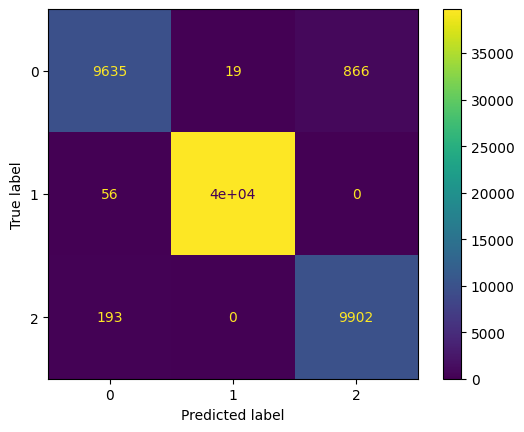

In [128]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [131]:
# Comparison of Model Classification Reports

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("XGBoost")
print(classification_report(y_test, xgb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.35      0.51     10520
           1       0.88      1.00      0.94     39781
           2       0.85      0.96      0.90     10095

    accuracy                           0.88     60396
   macro avg       0.88      0.77      0.78     60396
weighted avg       0.88      0.88      0.86     60396

Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     10520
           1       1.00      1.00      1.00     39781
           2       0.93      0.95      0.94     10095

    accuracy                           0.98     60396
   macro avg       0.96      0.96      0.96     60396
weighted avg       0.98      0.98      0.98     60396

Random Forest
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     10520
           1       1.00      1.00      1.00     39781
           2       0.92    

Cross validation

In [135]:
scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())
print(scores.std())

[0.97859966 0.9808349  0.97957241 0.97909595 0.9794685 ]
0.9795142850940692
0.0007431068637822209


Feture Importance

In [137]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

,Feature,Importance
2,DataValue,0.416843
7,DataSource_NVSS,0.166781
5,TopicID,0.153920
3,DataValueFootnoteID,0.103144
0,Year_Span,0.040122
9,DataSource_US Cancer DVT,0.039453
8,DataSource_Other,0.027685
6,StratificationGroupID,0.015546
4,LocationID,0.011054
1,LocationAbbr,0.009665


Sharp Value

/tmp/ipykernel_2776/2921476338.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy gl

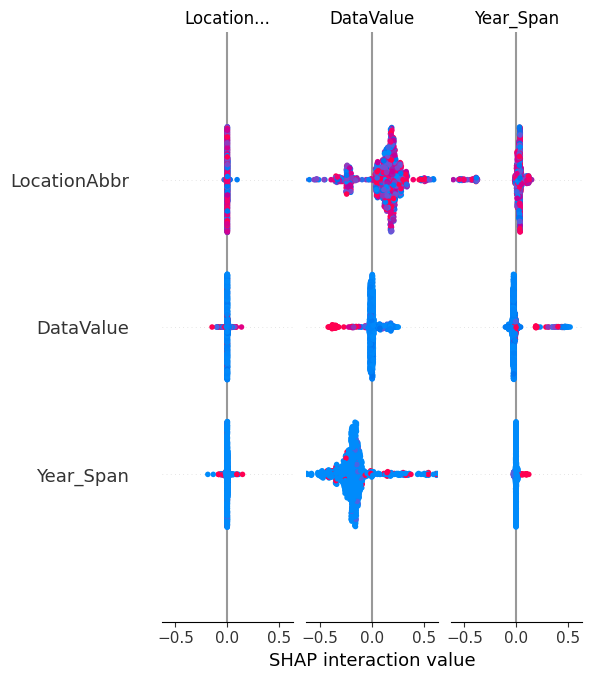

In [138]:
explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test[:1000])

shap.summary_plot(
    shap_values,
    X_test[:1000]
)

ROC Curve

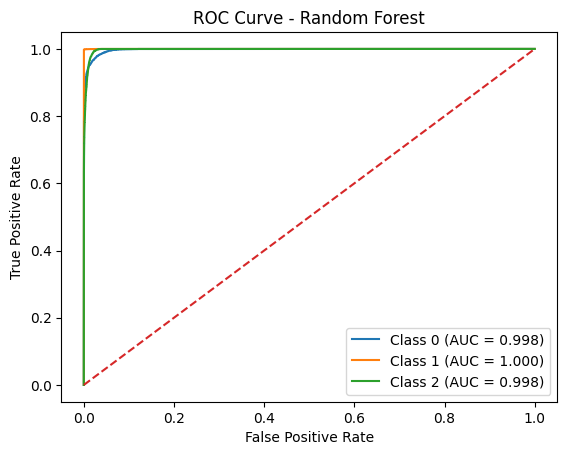

In [139]:
# Change classes to binary
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Probability
y_score = best_rf.predict_proba(X_test)

# ROC Curve
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC = {roc_auc:.3f})'
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [140]:
joblib.dump(best_lr, '/content/drive/MyDrive/LR_best.pkl')
joblib.dump(best_dt, '/content/drive/MyDrive/DT_best.pkl')
joblib.dump(best_rf, '/content/drive/MyDrive/RF_best.pkl')
joblib.dump(best_xgb, '/content/drive/MyDrive/XGB_best.pkl')

['/content/drive/MyDrive/XGB_best.pkl']

**To make model for DataValueTypeID**

In [141]:
# Create df_type for DataValueTypeID target
df_type = df1.copy()

print(f"df_type created with shape: {df_type.shape}")
print(f"Target column: DataValueTypeID")

df_type created with shape: (301979, 11)
Target column: DataValueTypeID


In [142]:
# One-Hot and Lable encoding

onehot_cols = [
    'DataSource',
    'DataValueUnit',
    'StratificationCategoryID1'
]

df_type = pd.get_dummies(
    df_type,
    columns=onehot_cols,
    drop_first=True
)

label_cols = [
    'LocationAbbr',
    'TopicID',
    'StratificationGroupID'
]

for col in label_cols:
    le = LabelEncoder()
    df_type[col] = le.fit_transform(df_type[col])

target_encoder = LabelEncoder()

df_type['DataValueTypeID'] = target_encoder.fit_transform(
    df_type['DataValueTypeID']
)

In [143]:
# Define X and y (y is DataValueTypeID)
X = df_type.drop(columns=['DataValueTypeID'])
y = df_type['DataValueTypeID']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Unique classes in y: {y.unique()}")

X_train shape: (241583, 17)
X_test shape: (60396, 17)
Unique classes in y: [8 7 2 6 1 5 0 4 3]


In [144]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [145]:
log_model = LogisticRegression(
    solver='liblinear',
    max_iter=3000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print(acc)

0.6687528975428836


In [146]:
# Creation Models for classification
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print()

Decision Tree:
  Accuracy: 0.7970

Random Forest:
  Accuracy: 0.7789

XGBoost:
  Accuracy: 0.8175



**Hyperparameter Tuning**

In [147]:
# Hyperparametr tuning for LogisticRegression with RandomizedSearchCV

param_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

lr = LogisticRegression(max_iter=2000)

grid_lr = RandomizedSearchCV(
    lr,
    param_lr,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_lr.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=LogisticRegression(max_iter=2000), n_iter=5,
                   n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'solver': ['liblinear']},
                   random_state=42, scoring='accuracy')

In [148]:
# Hyperparametr tuning for DecisionTreeClassifier with RandomizedSearchCV

param_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = RandomizedSearchCV(
    dt,
    param_dt,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_dt.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10]},
                   random_state=42, scoring='accuracy')

In [149]:
# Hyperparametr tuning for RandomForestClassifier with RandomizedSearchCV


param_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = RandomizedSearchCV(
    rf,
    param_rf,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_rf.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, scoring='accuracy')

In [150]:
# Hyperparametr tuning for XGBClassifier with RandomizedSearchCV


param_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_xgb = RandomizedSearchCV(
    xgb,
    param_xgb,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

grid_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, scoring='accuracy')

In [151]:
# Best Model for test prediction

best_lr = grid_lr.best_estimator_
lr_pred = best_lr.predict(X_test)
best_dt = grid_dt.best_estimator_
dt_pred = best_dt.predict(X_test)

best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test)

best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(X_test)

**Models Performance**

In [152]:
# Comparison of Model Classification Reports

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("XGBoost")
print(classification_report(y_test, xgb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.51      0.49      0.50      1308
           1       0.54      0.79      0.64     14590
           2       0.49      0.28      0.36      4689
           3       0.77      0.77      0.77      1106
           4       0.62      0.64      0.63      1693
           5       0.76      0.76      0.76      1066
           6       0.83      0.61      0.71     25191
           7       0.54      0.74      0.63      5406
           8       1.00      1.00      1.00      5347

    accuracy                           0.68     60396
   macro avg       0.67      0.68      0.67     60396
weighted avg       0.71      0.68      0.68     60396

Decision Tree
              precision    recall  f1-score   support

           0       0.65      0.72      0.68      1308
           1       0.71      0.86      0.78     14590
           2       0.68      0.77      0.72      4689
           3       0.92      0.87      0.90 

In [153]:
# As these resuls
  # Logistic Regression - weak
  # Decision Tree - The Best
  # Random Forest - Strong and stable (this situation is living rare time)
# XGBoost - The Best Balanced (Decision Tree and XGBoost balances are the same but XGBoost worked more balanced than Decision Tree in Classes)

**Confusion Matrix**

In [154]:
print(confusion_matrix(y_test, rf_pred))

[[  761     0     0     0   547     0     0     0     0]
 [    0 12087     0     0     0     0  2503     0     0]
 [    0     0  3142     0     0     0     0  1547     0]
 [    0     0     0   996     0   110     0     0     0]
 [  582     0     0     0  1111     0     0     0     0]
 [    0     0     0    66     0  1000     0     0     0]
 [    0  5081     0     0     0     0 20110     0     0]
 [    0     0  1720     0     0     0     0  3686     0]
 [    0     0     0     0     0     0     0     0  5347]]


In [155]:
# The best result is the last Class

In [156]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.679217
1,Decision Tree,0.817074
2,Random Forest,0.798728
3,XGBoost,0.821594


**SHARP Analisis**

In [157]:
# The Best Model is XGBoost. According to our sharp analysis will be with XGBoost
best_model = grid_xgb.best_estimator_

/tmp/ipykernel_2776/1593485794.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=X.columns)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plo

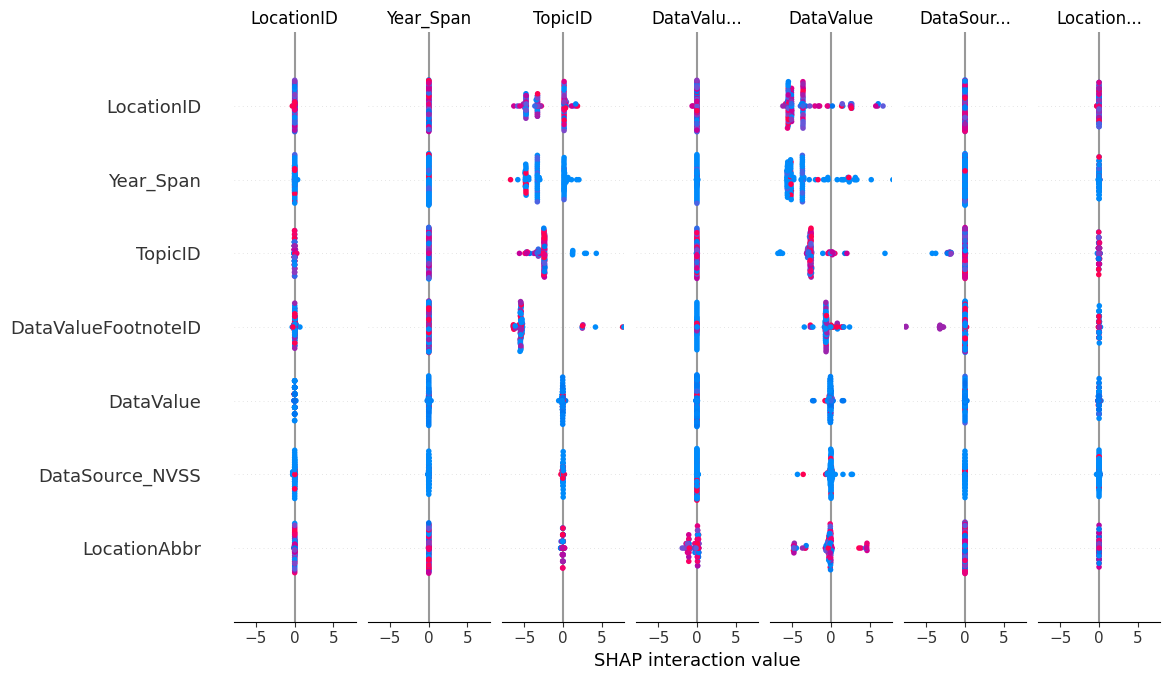

In [158]:
# Explainer for Tree-based models
explainer = shap.TreeExplainer(best_model)

# Litle sample
X_sample = X_test[:100]

# SHAP values
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample, feature_names=X.columns)

In [159]:
# The strongest features are DataValue, TopicID and LocationID that they are affect to Sharp values

**SHAP feature importance**

/tmp/ipykernel_2776/2855603204.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=X.columns, plot_type="bar")


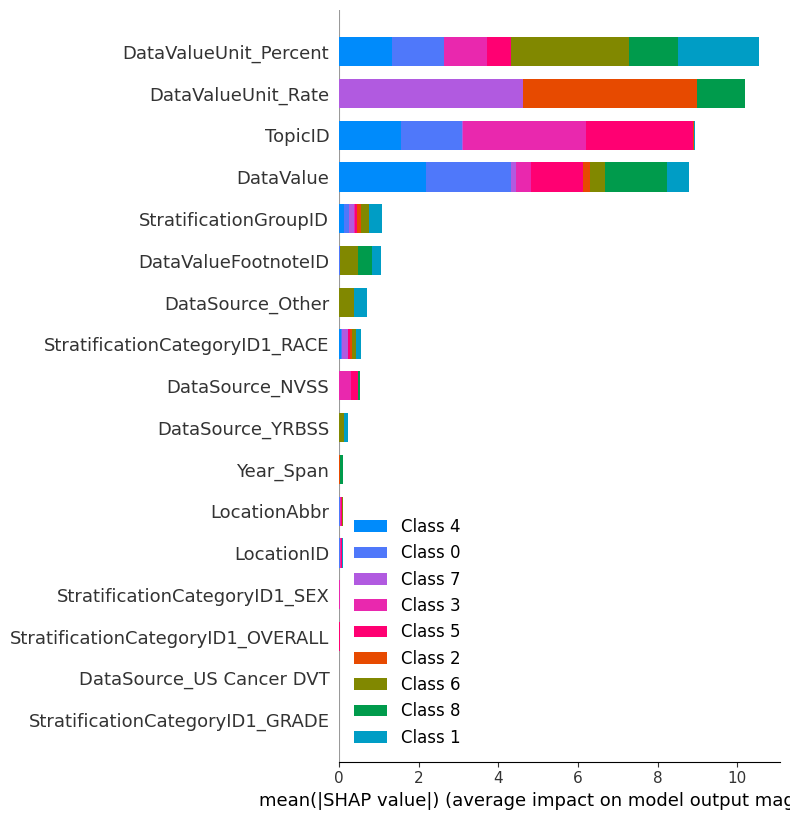

In [160]:
shap.summary_plot(shap_values, X_sample, feature_names=X.columns, plot_type="bar")

In [161]:
# Imortance Sharp features
    # DataValueUnit_Percent (The highest)
    # DataValueUnit_Rate
    # TopicID
    # DataValue

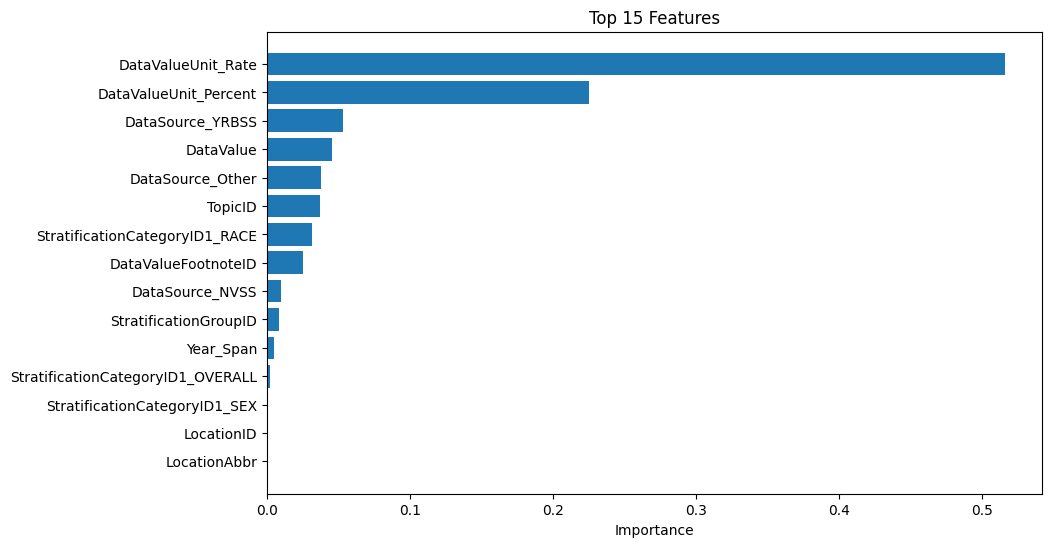

In [162]:
# Feature importance for Random Forest / XGBoost
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Features')
plt.gca().invert_yaxis()
plt.show()

In [163]:
# We have 2 importance. Sharp Importance feature and Feature imortance.
# Sharp importance (why is this importance and how will affect)
# Feature importance (Why importance)

**ROC Curves (For Classification)**

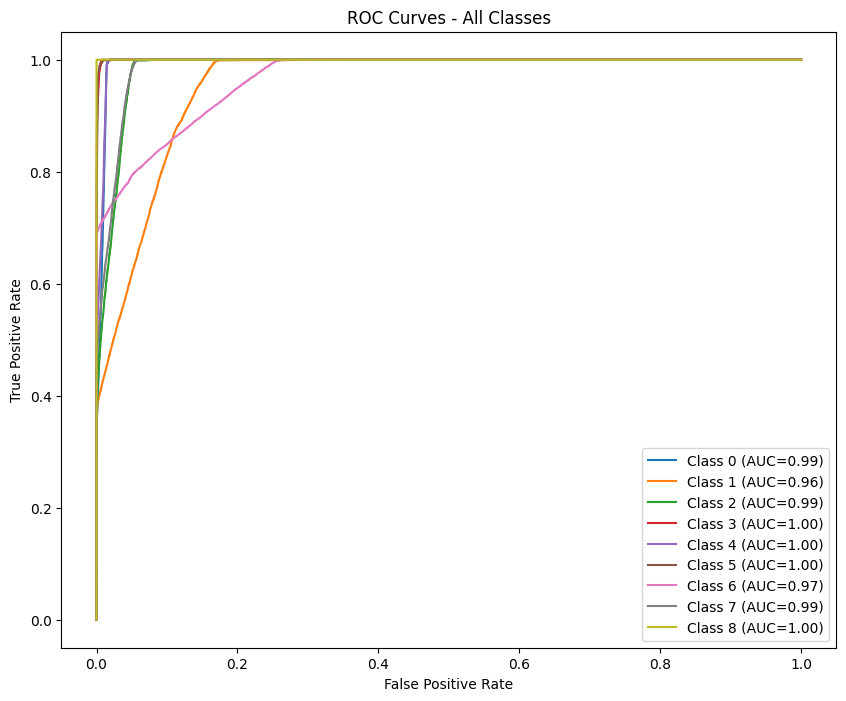

In [164]:
# For multiclass
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4,5,6,7,8])
y_pred_proba = best_model.predict_proba(X_test)

plt.figure(figsize=(10, 8))
for i in range(9):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc_score:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Classes')
plt.legend()
plt.show()

In [165]:
# ROC Curves results are best

**Error Analysis**

In [166]:
# Find misclassified samples
y_pred = best_model.predict(X_test)
misclassified = X_test[y_pred != y_test]

print(f"Total misclassified: {len(misclassified)}")
print(f"Misclassification rate: {len(misclassified)/len(X_test)*100:.2f}%")

# Show first 5 misclassified examples
print("\nFirst 5 misclassified samples:")
print(misclassified.head())

Total misclassified: 10775
Misclassification rate: 17.84%

First 5 misclassified samples:
        Year_Span  LocationAbbr  DataValue  DataValueFootnoteID  LocationID  \
117375          0             9      120.3                    2          12   
238836          0            38      114.0                    2          41   
149351          0            26       10.6                    1          28   
51999           0            13       15.2                    1          19   
218939          1            21       24.5                    1          24   

        TopicID  StratificationGroupID  DataSource_NVSS  DataSource_Other  \
117375        6                      8             True             False   
238836        7                     14             True             False   
149351        9                     14            False             False   
51999         7                      4            False             False   
218939        4                     12            

In [167]:
# Results are the same withe accuracy. Because Misclassification rate: 17.84% and accurancy - 82%

In [168]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

**Cross Validation**

In [169]:
# Cross-validation with best parameters
cv_scores = cross_val_score(best_model, X, y_encoded, cv=5, scoring='accuracy')

print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

CV Scores: [0.83030333 0.83118087 0.8203689  0.83318432 0.76759666]
Mean CV Score: 0.8165
Std CV Score: 0.0249


In [170]:
# All results are the best

In [171]:
joblib.dump(best_lr, '/content/drive/MyDrive/LR_best.pkl')
joblib.dump(best_dt, '/content/drive/MyDrive/DT_best.pkl')
joblib.dump(best_rf, '/content/drive/MyDrive/RF_best.pkl')
joblib.dump(best_xgb, '/content/drive/MyDrive/XGB_best.pkl')

['/content/drive/MyDrive/XGB_best.pkl']

In [172]:
def predict_new_data(features_df):
    """
    features_df: DataFrame with same columns as X
    """
    # Preprocess
    features_processed = features_df[X.columns]

    # Predict
    pred_encoded = best_model.predict(features_processed)
    pred_original = le.inverse_transform(pred_encoded)

    return pred_original

# Example
# new_predictions = predict_new_data(new_data)

In [173]:
# Create pipeline for easy deployment
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('model', best_model)
])

# Train on full data
pipeline.fit(X, y_encoded)

# Save pipeline
joblib.dump(pipeline, 'deployment_pipeline.pkl')

['deployment_pipeline.pkl']

In [174]:
# Parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBRegressor(random_state=42, verbosity=0)

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting Randomized Search...")
random_search.fit(X_train, y_train)

print("\nBest parameters:", random_search.best_params_)
print("Best R2 score (CV):", round(random_search.best_score_, 3))

# Evaluate best model
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"\nTest set performance:")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

Starting Randomized Search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best R2 score (CV): 0.622

Test set performance:
RMSE: 1.57
R2: 0.624


In [175]:
# After training all models, save them
joblib.dump(best_lr, models_path + 'LR_best.pkl')
joblib.dump(best_dt, models_path + 'DT_best.pkl')
joblib.dump(best_rf, models_path + 'RF_best.pkl')
joblib.dump(best_xgb, models_path + 'XGB_best.pkl')

print("✅ Models saved to Drive!")

✅ Models saved to Drive!
